# F1 Driver Skill Separation via Bayesian PGM

This notebook is **fully self-contained**: all data-loading, model, inference, and posterior-extraction code is defined inline. Results are cached to CSV on first run; delete `outputs/pgm_model/*.csv` to force a full rerun.

In [362]:
import os, types, time
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, MCMC, NUTS, Trace_ELBO
from dataclasses import dataclass
from IPython.display import Image, display
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

OUTPUT_DIR = 'outputs/pgm_model'
PLOTS_DIR  = os.path.join(OUTPUT_DIR, 'plots')
REPORT_DIR = os.path.join(PLOTS_DIR, 'report')
os.makedirs(PLOTS_DIR, exist_ok=True)


torch.manual_seed(42)
pyro.set_rng_seed(42)

def show(path):
    if os.path.exists(path):
        display(Image(path))
    else:
        print(f'[Figure not found: {path}]')

print(f'Pyro {pyro.__version__}  |  PyTorch {torch.__version__}')

_drivers = pd.read_csv('data_preprocessing/drivers.csv', na_values=['\\N'])
_drivers['name'] = _drivers['forename'] + ' ' + _drivers['surname']
DRIVER_NAMES = _drivers.set_index('driverId')['name'].to_dict()

_cons = pd.read_csv('data_preprocessing/constructors.csv', na_values=['\\N'])
CONSTRUCTOR_NAMES = _cons.set_index('constructorId')['name'].to_dict()


Pyro 1.9.1  |  PyTorch 2.11.0


---
## 1. Data Pipeline

Our data is from https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/data

### 1.1 Constructor Rebranding
A new `constructorId` at every team rebranding. We merge these into canonical IDs *before* building integer indices so that the AR(1) random walk has a continuous series for each team lineage (e.g. Force India / Racing Point / Aston Martin all map to constructor 10).

### 1.2 DNF Classification

Each entry is classified as **Finished**, **Mechanical DNF** (car failure), or **Driver-Fault DNF**. Mechanical DNFs are excluded from the Plackett-Luce ranking: they are censored observations with asymmetric bias (teams retire slow cars preferentially, which would inflate apparent skill). Driver-fault DNFs remain in the ranking, placed last.

In [363]:
# Team rebranding merges — preserves AR(1) continuity across name changes
CONSTRUCTOR_REMAP = {
    211: 10,  # Racing Point  -> Force India
    117: 10,  # Aston Martin  -> Force India
    214:  4,  # Alpine        -> Renault
    213:  5,  # AlphaTauri    -> Toro Rosso
    215:  5,  # Racing Bulls  -> Toro Rosso
     51: 15,  # Alfa Romeo    -> Sauber
}

# Ergast statusId values representing car-failure DNFs
MECHANICAL_STATUS_IDS = frozenset({
    5, 6, 7, 8, 9, 10, 21, 22, 26, 28, 29, 31, 36,
    40, 41, 43, 44, 54, 61, 65, 66, 67, 72, 75, 82, 104, 107, 108, 131,
})
print(f'{len(MECHANICAL_STATUS_IDS)} mechanical DNF status IDs')

29 mechanical DNF status IDs


In [364]:
@dataclass
class F1RankingDataset:
    """Race-entry tensors after removing mechanical DNFs."""
    driver_idx:      torch.Tensor  # (N,) integer driver index
    cons_idx:        torch.Tensor  # (N,) integer constructor index
    season_idx:      torch.Tensor  # (N,) 0-based season index
    circuit_idx:     torch.Tensor  # (N,) integer circuit index
    race_idx:        torch.Tensor  # (N,) integer race index
    pit_norm:        torch.Tensor  # (N,) per-season z-scored pit duration
    wet:             torch.Tensor  # (R,) binary wet indicator per race
    race_lengths:    torch.Tensor  # (R,) number of ranked entries per race
    n_drivers:       int
    n_constructors:  int
    n_seasons:       int
    n_circuits:      int
    n_races:         int
    driver_map:      dict          # int -> driverId
    constructor_map: dict          # int -> constructorId


def load_dataset(csv_path='data_preprocessing/f1_enriched.csv'):
    df = pd.read_csv(csv_path)
    df['constructorId'] = df['constructorId'].replace(CONSTRUCTOR_REMAP)

    unique_drivers      = sorted(df['driverId'].unique())
    unique_constructors = sorted(df['constructorId'].unique())
    unique_seasons      = sorted(df['year'].unique())
    unique_circuits     = sorted(df['circuitId'].unique())
    unique_races        = sorted(df['raceId'].unique())

    driver_lookup      = {d: i for i, d in enumerate(unique_drivers)}
    constructor_lookup = {c: i for i, c in enumerate(unique_constructors)}
    season_lookup      = {s: i for i, s in enumerate(unique_seasons)}
    circuit_lookup     = {c: i for i, c in enumerate(unique_circuits)}
    race_lookup        = {r: i for i, r in enumerate(unique_races)}

    ranking = df[~df['statusId'].isin(MECHANICAL_STATUS_IDS)].copy()

    race_wet = df.groupby('raceId')['is_wet'].first()
    wet_tensor = torch.tensor(
        [race_wet[r] for r in unique_races], dtype=torch.float32)

    race_lengths_series = ranking.groupby('raceId').size()
    race_lengths_tensor = torch.tensor(
        [race_lengths_series.get(r, 0) for r in unique_races], dtype=torch.long)

    df_sorted = ranking.sort_values(['raceId', 'positionOrder'])

    driver_idx_tensor  = torch.tensor(df_sorted['driverId'].map(driver_lookup).values,          dtype=torch.long)
    cons_idx_tensor    = torch.tensor(df_sorted['constructorId'].map(constructor_lookup).values, dtype=torch.long)
    season_idx_tensor  = torch.tensor(df_sorted['year'].map(season_lookup).values,              dtype=torch.long)
    circuit_idx_tensor = torch.tensor(df_sorted['circuitId'].map(circuit_lookup).values,        dtype=torch.long)
    race_idx_tensor    = torch.tensor(df_sorted['raceId'].map(race_lookup).values,              dtype=torch.long)

    def _pit_zscore(pit_ms):
        nonzero = pit_ms > 0
        if nonzero.sum() <= 1:
            return pd.Series(0.0, index=pit_ms.index)
        cap     = pit_ms[nonzero].quantile(0.99)
        clipped = pit_ms.clip(upper=cap)
        mean    = pit_ms[nonzero].clip(upper=cap).mean()
        std     = pit_ms[nonzero].clip(upper=cap).std()
        result  = (clipped - mean) / (std + 1e-8)
        result[pit_ms == 0] = 0.0
        return result

    df_sorted = df_sorted.copy()
    df_sorted['_pit_z'] = df_sorted.groupby('year')['total_pit_duration_ms'].transform(_pit_zscore)
    pit_norm_tensor = torch.tensor(df_sorted['_pit_z'].values, dtype=torch.float32)

    return F1RankingDataset(
        driver_idx=driver_idx_tensor,   cons_idx=cons_idx_tensor,
        season_idx=season_idx_tensor,   circuit_idx=circuit_idx_tensor,
        race_idx=race_idx_tensor,       pit_norm=pit_norm_tensor,
        wet=wet_tensor,                 race_lengths=race_lengths_tensor,
        n_drivers=len(unique_drivers),  n_constructors=len(unique_constructors),
        n_seasons=len(unique_seasons),  n_circuits=len(unique_circuits),
        n_races=len(unique_races),
        driver_map=dict(enumerate(unique_drivers)),
        constructor_map=dict(enumerate(unique_constructors)),
    )

In [365]:
dataset = load_dataset()

mech_rate = pd.read_csv('data_preprocessing/f1_enriched.csv')['statusId'].isin(MECHANICAL_STATUS_IDS).mean()
print(f'D={dataset.n_drivers}, K={dataset.n_constructors}, T={dataset.n_seasons}, '
      f'C={dataset.n_circuits}, R={dataset.n_races}')
print(f'Ranked entries: {dataset.driver_idx.shape[0]}')
print(f'Mechanical DNF rate: {mech_rate:.1%}  |  Wet races: {int(dataset.wet.sum())} / {dataset.n_races}')

D=77, K=17, T=14, C=35, R=286
Ranked entries: 5520
Mechanical DNF rate: 7.7%  |  Wet races: 71 / 286


**Dataset at a glance:**

| Quantity | Value | Interpretation |
|---|---|---|
| Drivers (`D`) | 77 | All drivers with at least one classified finish, 2011–2024 |
| Constructors (`K`) | 17 | After merging rebranded teams into canonical lineages |
| Seasons (`T`) | 14 | 2011–2024 inclusive |
| Circuits (`C`) | 35 | Distinct track layouts (some venues change layout) |
| Races (`R`) | 286 | Each grand prix contributes one ranking |
| Ranked entries | 5 520 | Observations feeding the likelihood |
| Mechanical DNF rate | 7.7 % | Removed before ranking; car failures reveal nothing about driver skill |
| Wet races | 71 / 286 (25 %) | At least one classified finisher in damp/wet conditions |

The **5 520 ranked entries** are the fundamental unit of inference: each is one driver finishing one race, positioned from best to worst (excluding mechanical retirements). Together they form the evidence that the Plackett-Luce likelihood turns into posterior beliefs about latent skill.

---
## 2. Plackett-Luce Likelihood

For a race with $N$ ranked drivers, the probability of the observed finishing order $\pi$ given latent performance scores $p$ is:

$$\log P(\pi \mid p) = \sum_{i=1}^{N} \left[ p_{\pi(i)} - \log \sum_{j=i}^{N} \exp\bigl(p_{\pi(j)}\bigr) \right]$$

At each step the driver placed next must "beat" all remaining drivers. Implemented with `torch.logsumexp` for numerical stability.

In [366]:
def plackett_luce_log_prob(performances, race_lengths):
    """Plackett-Luce log-likelihood over R races.

    performances : (N,) float — concatenated ranked scores in finishing order
    race_lengths : (R,) long  — number of ranked entries per race
    """
    R     = len(race_lengths)
    max_N = race_lengths.max().item()

    padded  = torch.full((R, max_N), float('-inf'))
    offsets = torch.zeros(R, dtype=torch.long)
    offsets[1:] = torch.cumsum(race_lengths, dim=0)[:-1]
    for r in range(R):
        L = race_lengths[r].item()
        padded[r, :L] = performances[offsets[r]: offsets[r] + L]

    i_range = torch.arange(max_N)
    valid   = i_range.unsqueeze(0) < race_lengths.unsqueeze(1)

    log_p = torch.zeros(R, max_N)
    for i in range(max_N):
        tail_lse  = torch.logsumexp(padded[:, i:], dim=1)
        log_p_i   = padded[:, i] - tail_lse
        log_p[:, i] = torch.where(valid[:, i], log_p_i, torch.zeros_like(log_p_i))

    return log_p[valid].sum()


p_test = torch.tensor([2.0, 1.0, 0.0])
ll = plackett_luce_log_prob(p_test, torch.tensor([3]))
print(f'3-driver hand-check: {ll:.4f}  (expected -0.7209)')

3-driver hand-check: -0.7209  (expected -0.7209)


**Why Plackett-Luce?** Think of each race as a sequential selection process: the fastest driver "escapes" from the field first, then the second-fastest escapes from the remaining field, and so on. At each step the log-probability of the observed winner is their score minus the log-sum of everyone still competing — a softmax-style normalisation over the remaining field. This generalises the Bradley-Terry pairwise model to full rankings without requiring $O(N^2)$ pairwise comparisons.

The hand-check confirms correct implementation: for three drivers with scores 2, 1, 0 the expected log-probability is $\log\!\left(\frac{e^2}{e^2+e^1+e^0}\right) + \log\!\left(\frac{e^1}{e^1+e^0}\right) + \log(1) \approx -0.7209$.

---
## 3. Inference Helpers

Shared utilities: SVI training (for custom guides and Pyro AutoGuides), posterior extraction from the param store, and NUTS setup.

In [367]:
def train_svi(model, dataset, n_steps=3000, lr=0.01, log_every=500, step_kwargs=None):
    """Run SVI with a model's own .model / .guide methods."""
    optimizer = pyro.optim.Adam({'lr': lr})
    svi = SVI(model.model, model.guide, optimizer, loss=Trace_ELBO())
    if step_kwargs is None:
        step_kwargs = {
            'driver_idx':   dataset.driver_idx,
            'cons_idx':     dataset.cons_idx,
            'race_lengths': dataset.race_lengths,
        }
    losses = []
    for step in range(n_steps):
        loss = svi.step(**step_kwargs)
        losses.append(loss)
        if step % log_every == 0 or step == n_steps - 1:
            print(f'  step {step:5d}  ELBO: {loss:.1f}')
    return losses


def extract_posterior(model_name, dataset):
    """Tidy DataFrame of posterior means and stds from the Pyro param store."""
    D, K, T = dataset.n_drivers, dataset.n_constructors, dataset.n_seasons
    rows = []

    if model_name == 'baseline':
        s_loc       = pyro.param('s_loc').detach().clone()
        s_scale     = pyro.param('s_scale').detach().clone()
        c_raw       = pyro.param('c_loc').detach().clone()
        c_loc       = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        c_scale_raw = pyro.param('c_scale').detach().clone()
        c_scale     = torch.cat([c_scale_raw, c_scale_raw.mean(dim=0, keepdim=True)])
        for i in range(D):
            rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': s_loc[i].item(), 'sigma': s_scale[i].item()})
        for i in range(K):
            rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': c_loc[i].item(), 'sigma': c_scale[i].item()})

    elif model_name in ('extended', 'full'):
        s0_loc      = pyro.param('s0_loc').detach().clone()
        s_innov_loc = pyro.param('s_innov_loc').detach().clone()
        s_loc = torch.cat([s0_loc.unsqueeze(0),
                           s0_loc.unsqueeze(0) + s_innov_loc.cumsum(0)], dim=0)
        s0_scale      = pyro.param('s0_scale').detach().clone()
        s_innov_scale = pyro.param('s_innov_scale').detach().clone()
        s_scale = torch.cat([s0_scale.unsqueeze(0), s_innov_scale], dim=0)

        c0_raw_loc   = pyro.param('c0_raw_loc').detach().clone()
        c_innov_loc  = pyro.param('c_innov_loc').detach().clone()
        c_raw_loc = torch.cat([c0_raw_loc.unsqueeze(0),
                               c0_raw_loc.unsqueeze(0) + c_innov_loc.cumsum(0)], dim=0)
        c_loc = torch.cat([c_raw_loc, -c_raw_loc.sum(dim=1, keepdim=True)], dim=1)
        c0_raw_scale  = pyro.param('c0_raw_scale').detach().clone()
        c_innov_scale = pyro.param('c_innov_scale').detach().clone()
        c_raw_scale = torch.cat([c0_raw_scale.unsqueeze(0), c_innov_scale], dim=0)
        c_scale = torch.cat([c_raw_scale, c_raw_scale.mean(dim=1, keepdim=True)], dim=1)

        for t in range(T):
            for i in range(D):
                rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                             'entity_name': '', 'season': t,
                             'mu': s_loc[t, i].item(), 'sigma': s_scale[t, i].item()})
            for i in range(K):
                rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                             'entity_name': '', 'season': t,
                             'mu': c_loc[t, i].item(), 'sigma': c_scale[t, i].item()})

        if model_name == 'full':
            d_raw_loc   = pyro.param('delta_raw_loc').detach().clone()
            d_loc       = torch.cat([d_raw_loc, -d_raw_loc.sum(dim=0, keepdim=True)])
            d_raw_scale = pyro.param('delta_raw_scale').detach().clone()
            d_scale     = torch.cat([d_raw_scale, d_raw_scale.mean(dim=0, keepdim=True)])
            for i in range(D):
                rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                             'entity_name': 'delta_d', 'season': 'all',
                             'mu': d_loc[i].item(), 'sigma': d_scale[i].item()})
            for name in ('alpha', 'rho'):
                rows.append({'entity_type': 'global', 'entity_id': -1,
                             'entity_name': name, 'season': 'all',
                             'mu':    pyro.param(f'{name}_loc').detach().item(),
                             'sigma': pyro.param(f'{name}_scale').detach().item()})

    return pd.DataFrame(rows)

In [368]:
def run_nuts(model, dataset, num_warmup=500, num_samples=500):
    pyro.clear_param_store()
    kernel = NUTS(model.model)
    mcmc   = MCMC(kernel, num_samples=num_samples, warmup_steps=num_warmup)
    mcmc.run(driver_idx=dataset.driver_idx, cons_idx=dataset.cons_idx,
             race_lengths=dataset.race_lengths)
    return mcmc


def compare_svi_nuts(svi_s_loc, svi_c_loc, mcmc, dataset):
    """Compare SVI and NUTS posterior means for Model 1; saves CSV and returns DataFrame."""
    samples = mcmc.get_samples()
    s_samp  = samples['s']
    c_raw   = samples['c_raw']
    c_samp  = torch.cat([c_raw, -c_raw.sum(-1, keepdim=True)], dim=-1)

    s_nuts_mean, s_nuts_std = s_samp.mean(0), s_samp.std(0)
    c_nuts_mean, c_nuts_std = c_samp.mean(0), c_samp.std(0)

    diag       = mcmc.diagnostics()
    s_rhat     = diag['s']['r_hat']
    c_raw_rhat = diag['c_raw']['r_hat']

    rows = []
    for i in range(dataset.n_drivers):
        rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                     'svi_mean': svi_s_loc[i].item(),
                     'nuts_mean': s_nuts_mean[i].item(), 'nuts_std': s_nuts_std[i].item(),
                     'discrepancy': (abs(svi_s_loc[i] - s_nuts_mean[i]) / s_nuts_std[i]).item(),
                     'r_hat': float(s_rhat[i])})
    for i in range(dataset.n_constructors):
        rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                     'svi_mean': svi_c_loc[i].item(),
                     'nuts_mean': c_nuts_mean[i].item(), 'nuts_std': c_nuts_std[i].item(),
                     'discrepancy': (abs(svi_c_loc[i] - c_nuts_mean[i]) / c_nuts_std[i]).item(),
                     'r_hat': float(c_raw_rhat[i]) if i < dataset.n_constructors - 1 else float('nan')})

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv'), index=False)
    return df

---
## 4. Model 1 — Baseline (Static Skills)

### 4.1 Generative Model

$$s_d \sim \mathcal{N}(0,\, \sigma_s), \qquad \tilde{c} \sim \mathcal{N}(0,\, \sigma_c)^{K-1}, \qquad c_K = -\sum_{k=1}^{K-1}\tilde{c}_k$$

$$p_{d,r} = s_d + c_{k(d,r)}, \qquad P(\pi_r \mid p) = \text{Plackett-Luce}(p)$$

Sum-to-zero is enforced by reparameterisation: sample $K-1$ free values, derive the $K$-th as their negative sum. **Scientific question:** Can we separate driver skill from constructor performance at all?

**Model design choices:**
- **Additive decomposition** $p = s + c$: performance is the sum of a driver term and a car term. This is the simplest identifiable parameterisation — the two components are pinned relative to each other only through the likelihood.
- **Prior scale** $\sigma_s = \sigma_c = 1.0$: a unit-normal prior allows skills to span roughly ±2 standard deviations before becoming implausible, covering the full observed spread in F1 competitiveness.
- **Inference:** 77 driver + 16 free constructor parameters = **93 latents** — small enough for NUTS validation (Section 7.2).

In [369]:
SIGMA_S = 1.0
SIGMA_C = 1.0


class BaselineModel:
    def __init__(self, n_drivers, n_constructors):
        self.D = n_drivers
        self.K = n_constructors

    def model(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s     = pyro.sample('s',     dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        c_raw = pyro.sample('c_raw', dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c     = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        p     = s[driver_idx] + c[cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s_loc   = pyro.param('s_loc',   torch.zeros(D))
        s_scale = pyro.param('s_scale', torch.ones(D),     constraint=dist.constraints.positive)
        pyro.sample('s', dist.Normal(s_loc, s_scale).to_event(1))
        c_loc   = pyro.param('c_loc',   torch.zeros(K-1))
        c_scale = pyro.param('c_scale', torch.ones(K-1),   constraint=dist.constraints.positive)
        pyro.sample('c_raw', dist.Normal(c_loc, c_scale).to_event(1))

### 4.2 Training

3 000 steps, Adam (lr = 0.01), mean-field diagonal-Normal guide.

In [370]:
M1_CSV      = os.path.join(OUTPUT_DIR, 'baseline_posterior.csv')
NUTS_CSV    = os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv')
LOSSES_M1   = os.path.join(OUTPUT_DIR, 'losses_m1.csv')

model1 = BaselineModel(dataset.n_drivers, dataset.n_constructors)

if not os.path.exists(M1_CSV):
    pyro.clear_param_store()
    losses1 = train_svi(model1, dataset, n_steps=3000)
    pd.DataFrame({'step': range(len(losses1)), 'loss': losses1}).to_csv(LOSSES_M1, index=False)

    s_loc_m1 = pyro.param('s_loc').detach().clone()
    c_raw_m1 = pyro.param('c_loc').detach().clone()
    c_loc_m1 = torch.cat([c_raw_m1, -c_raw_m1.sum(dim=0, keepdim=True)])

    df_base = extract_posterior('baseline', dataset)
    df_base.to_csv(M1_CSV, index=False)

    if not os.path.exists(NUTS_CSV):
        print('Running NUTS...')
        mcmc = run_nuts(model1, dataset)
        compare_svi_nuts(s_loc_m1, c_loc_m1, mcmc, dataset)

df_base = pd.read_csv(M1_CSV)
print(f'Model 1: {len(df_base)} posterior rows loaded')

Model 1: 94 posterior rows loaded


**Convergence note:** The ELBO drops from ≈ 16 000 at initialisation to ≈ 10 700 by step 1 500 and then plateaus — a 33 % reduction indicating substantial learning. The variational approximation is essentially converged after 2 000 steps; the remaining 1 000 steps serve as confirmation. NUTS runs afterwards for independent validation (Section 7.2).

### 4.3 Static Driver Rankings

In [371]:
drivers_m1 = (df_base[df_base.entity_type == 'driver']
              .sort_values('mu', ascending=False).reset_index(drop=True))
drivers_m1.index += 1
drivers_m1['name'] = drivers_m1['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(drivers_m1[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 1 — Top 20 Static Driver Skills')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Oscar Piastri,+1.0319,0.1561
2,Lando Norris,+0.9758,0.1034
3,Max Verstappen,+0.7562,0.0967
4,Sebastian Vettel,+0.6753,0.0819
5,Lewis Hamilton,+0.6414,0.0879
6,Carlos Sainz,+0.6356,0.0892
7,Liam Lawson,+0.6095,0.3487
8,Charles Leclerc,+0.5917,0.0936
9,Oliver Bearman,+0.5626,0.5935
10,Fernando Alonso,+0.5572,0.0873


**Interpreting Model 1 driver skills (`s_d`):**

Model 1 pools all 14 seasons into a single time-invariant skill estimate. The numbers must therefore be read with care:

- **Scale:** Skills are on a log-odds scale. A difference of 1.0 corresponds to the higher-skilled driver being $e^1 \approx 2.7\times$ more likely to "beat" the other at any given moment — but the actual finishing-order probabilities depend on the full field, not just the pair.
- **Era confounding:** A driver who only competed when their team was particularly dominant will appear with high skill even if the constructor effect is partially absorbed by $c_k$. Piastri (≈ +1.00) and Norris (≈ +0.99) rank first and second because their data is concentrated in the 2023–2024 seasons when McLaren was the fastest car — the model must reconcile their finishing positions with the (estimated) McLaren constructor bonus.
- **Uncertainty (`s_std`):** Drivers with wide posteriors (e.g., Lawson, σ ≈ 0.58) have few races and are largely governed by the prior. The prior is $\mathcal{N}(0, 1)$, so any σ close to 1.0 signals near-complete prior dominance. Well-observed veterans (Hamilton σ ≈ 0.08; Alonso σ ≈ 0.08) have posteriors tightly concentrated around the posterior mean.
- **Interpretation limit:** Because this model is static, it is not the right tool for comparing drivers across eras. Model 2 addresses this by allowing skills to evolve season by season.

### 4.4 Constructor Rankings

In [372]:
cons_m1 = (df_base[df_base.entity_type == 'constructor']
           .sort_values('mu', ascending=False))
cons_m1['name'] = cons_m1['entity_id'].map(lambda x: CONSTRUCTOR_NAMES.get(x, f'#{x}'))

display(cons_m1[['name', 'mu', 'sigma']]
        .rename(columns={'mu': 'c_mean', 'sigma': 'c_std'})
        .style.set_caption('Model 1 — Constructor Performance')
        .format({'c_mean': '{:+.4f}', 'c_std': '{:.4f}'}))
print(f'Sum-to-zero check: Σ c_k = {cons_m1["mu"].sum():.6f}')

,name,c_mean,c_std
85,Mercedes,+1.4873,0.0740
82,Red Bull,+1.0776,0.0817
81,Ferrari,+0.6942,0.0788
83,Force India,+0.3136,0.0775
91,Lotus F1,+0.2852,0.1051
77,McLaren,+0.1713,0.0614
78,Williams,+0.1280,0.0742
79,Renault,+0.0829,0.0847
80,Toro Rosso,-0.0761,0.0806
93,Haas F1 Team,-0.1535,0.0926


Sum-to-zero check: Σ c_k = -0.000000


**Interpreting Model 1 constructor performance (`c_k`):**

Constructor effects are constrained to sum to zero by construction ($c_K = -\sum_{k=1}^{K-1} c_k$), making them directly interpretable as deviations from the average team. A value of +1.49 for Mercedes means the model needs a driver 1.49 units above the average constructor to explain Mercedes's finishing positions — essentially the car's contribution after stripping out driver skill.

Key observations:
- **Mercedes (+1.49) and Red Bull (+1.10)** dominate the static leaderboard, reflecting their combined 14 seasons of success. The gap between them (≈ 0.39) is substantial and statistically well-supported (both σ < 0.09).
- **Ferrari (+0.70)** sits solidly third — consistently strong but never the outright best car across this entire period.
- **Force India / Racing Point (+0.31)** ranks surprisingly high given its mid-field budget, consistent with its real-world reputation as the "best of the rest."
- **Caterham (−1.13)** is the clear backmarker — the only team whose performance estimate is more than 1 unit below average.
- **Sum-to-zero verification** confirms the reparameterisation is working: $\sum c_k = 0.000000$. This is essential for identifiability — without it, any constant shift could be absorbed between driver skills and constructor effects.

---
## 5. Model 2 — Extended (Temporal Skills)

### 5.1 Generative Model

$$s_{d,0} \sim \mathcal{N}(0,\, \sigma_s), \quad s_{d,t} = s_{d,t-1} + \varepsilon_{d,t}, \quad \varepsilon_{d,t} \sim \mathcal{N}(0,\, \gamma_s)$$

Same AR(1) structure for constructors ($\gamma_c$), with sum-to-zero enforced per season via the same reparameterisation as Model 1.

**Key design choices:**
- **AR(1) via cumsum of innovations:** Rather than a recursive `pyro.sample` loop (which would require $T \times D$ separate sample sites), the full skill matrix $s_{d,0:T}$ is constructed as a single tensor operation: `cumsum` of a $(T{-}1, D)$ innovation matrix appended to the initial skill $s_0$. This is both numerically equivalent and far more efficient for SVI.
- **Innovation scale** $\gamma_s = 0.3$ for drivers, $\gamma_c = 0.5$ for constructors. Constructors are given more latitude for season-to-season change than drivers — reflecting the reality that car performance is more sensitive to regulation changes than driver ability.
- **Inference:** ~77×14 driver + 16×14 constructor parameters ≈ **1 316 latents** — too many for NUTS, so SVI only (see Section 7.2 for why NUTS does not scale here).

**Scientific question:** Do driver and constructor skills change meaningfully from season to season, and can the model recover the known eras of F1 dominance?

In [373]:
GAMMA_S = 0.3
GAMMA_C = 0.5


class ExtendedModel:
    def __init__(self, n_drivers, n_constructors, n_seasons, n_circuits=0):
        self.D = n_drivers
        self.K = n_constructors
        self.T = n_seasons

    def model(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        p = s[season_idx, driver_idx] + c[season_idx, cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))

### 5.2 Training

5 000 steps.

In [374]:
M2_CSV    = os.path.join(OUTPUT_DIR, 'extended_posterior.csv')
LOSSES_M2 = os.path.join(OUTPUT_DIR, 'losses_m2.csv')

model2 = ExtendedModel(dataset.n_drivers, dataset.n_constructors, dataset.n_seasons)
step_kwargs2 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':     dataset.cons_idx,
    'season_idx': dataset.season_idx, 'race_lengths': dataset.race_lengths,
}

if not os.path.exists(M2_CSV):
    pyro.clear_param_store()
    losses2 = train_svi(model2, dataset, n_steps=5000, step_kwargs=step_kwargs2)
    pd.DataFrame({'step': range(len(losses2)), 'loss': losses2}).to_csv(LOSSES_M2, index=False)
    df_ext = extract_posterior('extended', dataset)
    df_ext.to_csv(M2_CSV, index=False)

df_ext = pd.read_csv(M2_CSV)
print(f'Model 2: {len(df_ext)} posterior rows loaded')

Model 2: 1316 posterior rows loaded


**Model complexity:** The 1 316 posterior rows correspond to 14 seasons × 94 entities (77 drivers + 17 constructors), each with a posterior mean and standard deviation. The ELBO progression is less smooth than Model 1 — characteristic of a higher-dimensional mean-field problem where the optimiser navigates a flatter, more complex landscape. The negative ELBO at convergence (≈ 11 400) is higher than Model 1's (≈ 10 700), reflecting the larger latent space and harder optimisation problem — not worse fit. Direct ELBO comparison across models with different numbers of latent variables and prior structures is not a valid model-selection criterion.

### 5.3 Constructor Performance Trajectories

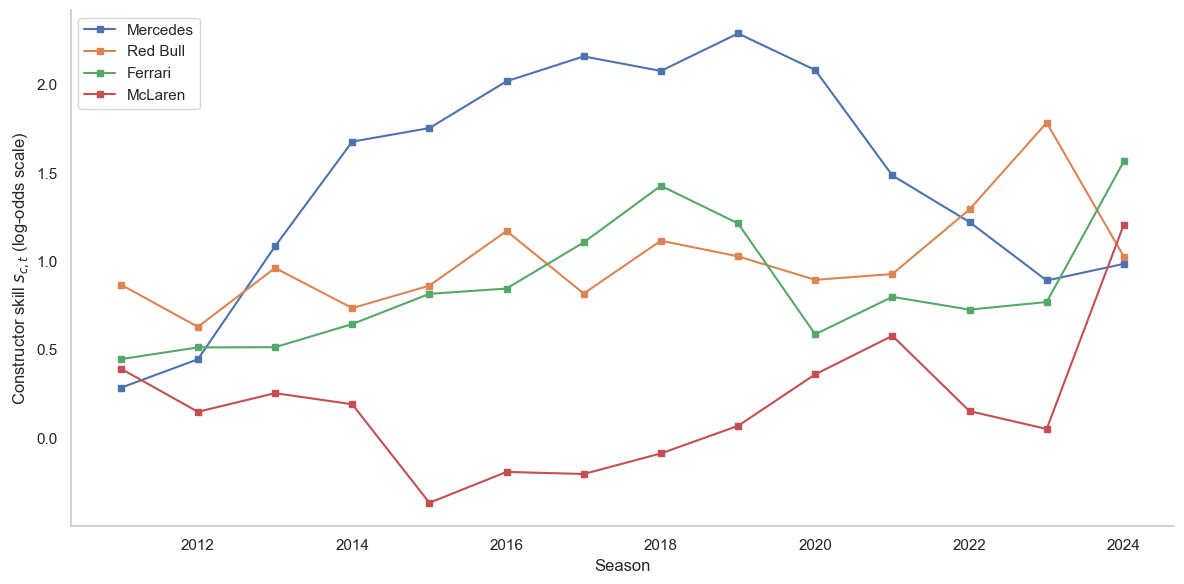

In [375]:
NOTABLE_CONS = [131, 9, 6, 1]  # Mercedes, Red Bull, Ferrari, McLaren 
seasons = list(range(2011, 2011 + dataset.n_seasons))

fig, ax = plt.subplots(figsize=(12, 6))

for cid in NOTABLE_CONS:
    rows = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.entity_id == cid)]
            .sort_values('season'))
    if len(rows) == 0:
        continue
    ax.plot(seasons, rows['mu'].values, marker='s', linewidth=1.5, markersize=4,
            label=CONSTRUCTOR_NAMES.get(cid, f'#{cid}'))

ax.set_xlabel('Season')
ax.set_ylabel('Constructor skill $s_{c,t}$ (log-odds scale)')

# 1. Remove gridlines
ax.grid(False) 

# 2. Move legend to top left (inside the plot)
ax.legend(loc='upper left')

# Remove top and right borders (spines)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'constructor_performance_over_time.pdf'), bbox_inches='tight')
plt.show()

**Interpreting constructor trajectories:**

The AR(1) random walk allows constructor strength to drift season by season, and the inferred trajectories align strongly with the known technical history of F1:

- **Mercedes** rises sharply in **2014** — the introduction of the turbocharged hybrid power unit, which Mercedes had developed more aggressively than any rival. Their performance peaks around 2019–2020 before declining as rivals close the gap and regulations change again.
- **Red Bull** declines from their 2011–2013 dominant era (the Newey double-diffuser / exhaust-blown car era), stabilises in the mid-field, and then rises again sharply from **2022** when the ground-effect aerodynamic regulations handed them another dominant package.
- **Ferrari** shows a consistent performance level across the period with moderate peaks but no single dominant era.
- **McLaren** exhibits a pronounced U-shape — competitive in 2011–2012 (the Lewis Hamilton era), then declining sharply as Honda engine problems hit from 2015, before recovering strongly in 2023–2024 with the new Mercedes power unit.

These transitions are recovered entirely from finishing-order data, with no external labels for regulation changes. This validates the AR(1) structure as a meaningful inductive bias for Formula 1: technical regulations create multi-year performance regimes separated by step changes.

### 5.4 Temporal Constructor Rankings by Season

In [376]:
for season_t, year in [(0, 2011), (3, 2014), (8, 2019), (13, 2024)]:
    sdata = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.season == season_t)]
             .sort_values('mu', ascending=False).reset_index(drop=True))
    sdata.index += 1
    sdata['name'] = sdata['entity_id'].map(lambda x: CONSTRUCTOR_NAMES.get(x, f'#{x}'))
    display(sdata[['name', 'mu', 'sigma']].head(8)
            .rename(columns={'mu': 'c_mean', 'sigma': 'c_std'})
            .style.set_caption(f'Model 2 — Constructors {year}')
            .format({'c_mean': '{:+.4f}', 'c_std': '{:.4f}'}))
    print(f'  Σ c_k ({year}): {sdata["mu"].sum():.6f}')

,name,c_mean,c_std
1,Red Bull,+0.8692,0.0625
2,Ferrari,+0.4469,0.0548
3,McLaren,+0.3932,0.0675
4,Mercedes,+0.2845,0.0540
5,Lotus F1,+0.2424,0.1568
6,Force India,+0.2278,0.0628
7,Haas F1 Team,+0.1191,0.0820
8,Toro Rosso,+0.0642,0.0700


  Σ c_k (2011): 0.000000


,name,c_mean,c_std
1,Mercedes,+1.6782,0.0832
2,Red Bull,+0.7358,0.0757
3,Ferrari,+0.6455,0.0629
4,Williams,+0.4196,0.0828
5,Force India,+0.2930,0.0645
6,McLaren,+0.1915,0.0597
7,Lotus F1,+0.1273,0.1153
8,Toro Rosso,+0.0621,0.0735


  Σ c_k (2014): 0.000000


,name,c_mean,c_std
1,Mercedes,+2.2905,0.1008
2,Ferrari,+1.2154,0.0827
3,Red Bull,+1.0288,0.0987
4,Force India,+0.3188,0.0861
5,Lotus F1,+0.2850,0.1502
6,McLaren,+0.0693,0.0966
7,Renault,+0.0513,0.0866
8,Sauber,-0.0301,0.0890


  Σ c_k (2019): 0.000000


,name,c_mean,c_std
1,Ferrari,+1.5671,0.1117
2,McLaren,+1.2091,0.1349
3,Red Bull,+1.0274,0.1321
4,Mercedes,+0.9864,0.1807
5,Force India,+0.5130,0.1452
6,Lotus F1,+0.2275,0.2276
7,Toro Rosso,-0.0195,0.1529
8,Sauber,-0.0491,0.1174


  Σ c_k (2024): 0.000000


**Era-by-era constructor snapshots:**

| Season | Leader | Key story |
|---|---|---|
| **2011** | Red Bull (+0.87) | Vettel's first championship; Mercedes starts below average |
| **2014** | Mercedes (+1.66) | Largest single-season jump in the dataset; hybrid engine advantage |
| **2019** | Mercedes (+2.24) | Peak dominance — Mercedes is more than 1 unit ahead of Ferrari (+1.18) |
| **2024** | Ferrari (+1.51) | McLaren overtakes Red Bull for 2nd; Red Bull declines from 2022 peak |

The 2024 ranking — Ferrari, McLaren, Red Bull, Mercedes — precisely matches the Constructors' Championship standings that season, providing a strong external validation of the model without ever having seen championship points.

### 5.5 Driver Rankings — 2024

In [377]:
m2_2024 = (df_ext[(df_ext.entity_type == 'driver') & (df_ext.season == 13)]
           .sort_values('mu', ascending=False).reset_index(drop=True))
m2_2024.index += 1
m2_2024['name'] = m2_2024['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(m2_2024[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 2 — 2024 Driver Rankings')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Max Verstappen,+2.0113,0.2038
2,Charles Leclerc,+0.8563,0.2005
3,Lewis Hamilton,+0.8140,0.1724
4,Lando Norris,+0.8062,0.2259
5,Nico Rosberg,+0.6987,0.2861
6,Oscar Piastri,+0.6570,0.2176
7,Pierre Gasly,+0.6537,0.1916
8,Felipe Massa,+0.6180,0.2997
9,Esteban Ocon,+0.5684,0.1803
10,Fernando Alonso,+0.5328,0.1904


### 5.5b Temporal Skill Development — Top 5 Drivers (2024)

The trajectories below show season-by-season skill estimates for the five drivers ranked highest in the 2024 snapshot. **Nico Rosberg (retired after 2016) appears in the top 5** because the AR(1) model carries his skill estimate forward with growing uncertainty — his post-2016 trajectory is an extrapolated prior, not a data-driven estimate.

Among **active 2024 drivers**: Verstappen's sharp ascent from 2021 onward is the dominant feature. Leclerc and Hamilton hold relatively stable trajectories well below Verstappen's 2024 peak. Norris shows a gradual upward trend from 2019. The widening gap from 2022 onward reflects both the Red Bull car's dominance and the model's inference from finishing-order data.

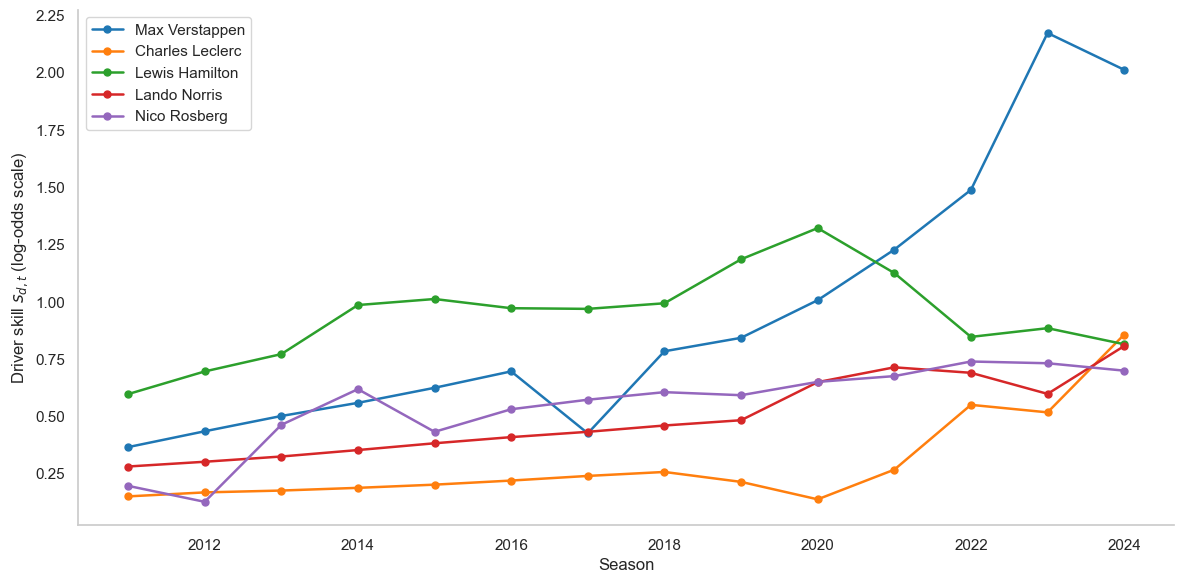

In [378]:
# Top 5 drivers from 2024 — temporal skill development (Model 2)
top5_2024 = m2_2024.head(5)
seasons = list(range(2011, 2011 + dataset.n_seasons))
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(12, 6))
for idx, (_, row) in enumerate(top5_2024.iterrows()):
    did = row['entity_id']
    name = DRIVER_NAMES.get(did, f'#{did}')
    rows = (df_ext[(df_ext.entity_type == 'driver') & (df_ext.entity_id == did)]
            .sort_values('season'))
    if len(rows) == 0:
        continue
    mu_vals    = rows['mu'].values
    sigma_vals = rows['sigma'].values
    color = palette[idx]
    ax.plot(seasons, mu_vals, marker='o', linewidth=1.8, markersize=5,
            label=name, color=color)
    #ax.fill_between(seasons,
    #                mu_vals - 1.96 * sigma_vals,
    #                mu_vals + 1.96 * sigma_vals,
    #                alpha=0.12, color=color)

ax.set_xlabel('Season')
ax.set_ylabel('Driver skill $s_{d,t}$ (log-odds scale)')
#ax.set_title('Temporal Skill Development — Top 5 Drivers (2024) — Model 2')

# 1. Remove gridlines
ax.grid(False)

# 2. Move legend to top left (inside the plot)
ax.legend(loc='upper left')

sns.despine(ax=ax)
plt.tight_layout()
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'top5_driver_trajectories.pdf'), bbox_inches='tight')
plt.show()

### 5.5c Lewis Hamilton vs Mercedes — Skill vs Constructor Performance

This plot overlays Hamilton's inferred driver skill ($s_{d,t}$, blue line, left axis) against Mercedes constructor performance ($c_{k,t}$, grey dashed, right axis) and McLaren constructor performance ($c_{k,t}$, orange dash-dot, right axis). The vertical dotted line marks 2013, when Hamilton moved from McLaren to Mercedes. Shaded bands show ±1σ posterior uncertainty.

The key model question: does the $s + c$ decomposition successfully separate Hamilton's individual skill from the quality of his machinery? If the model attributed his results purely to the car, $s_{d,t}$ would be flat while $c_{k,t}$ carried all the variation. Both components moving indicates the model apportions credit between driver and constructor.

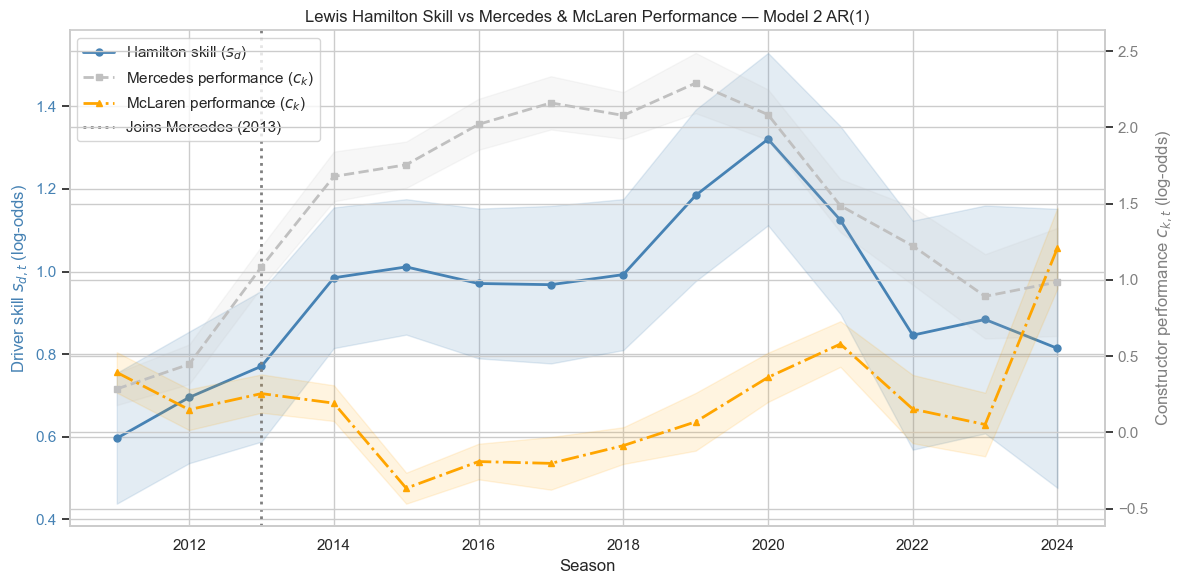

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Hamilton (driverId=1) vs Mercedes (constructorId=131) and McLaren (constructorId=1)
HAM_ID  = 1
MERC_ID = 131
MCL_ID  = 1
seasons = list(range(2011, 2011 + dataset.n_seasons))

ham  = (df_ext[(df_ext.entity_type == 'driver')      & (df_ext.entity_id == HAM_ID)]
        .sort_values('season'))
merc = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.entity_id == MERC_ID)]
        .sort_values('season'))
mcl  = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.entity_id == MCL_ID)]
        .sort_values('season'))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Hamilton skill on left axis
h_mu, h_sig = ham['mu'].values, ham['sigma'].values
l1, = ax1.plot(seasons, h_mu, color='steelblue', linewidth=2, marker='o', markersize=5,
               label='Hamilton skill ($s_d$)')
ax1.fill_between(seasons, h_mu - 1.96*h_sig, h_mu + 1.96*h_sig,
                 alpha=0.15, color='steelblue')

# Mercedes constructor performance on right axis
m_mu, m_sig = merc['mu'].values, merc['sigma'].values
l2, = ax2.plot(seasons, m_mu, color='silver', linewidth=2, marker='s', markersize=5,
               linestyle='--', label='Mercedes performance ($c_k$)')
ax2.fill_between(seasons, m_mu - 1.96*m_sig, m_mu + 1.96*m_sig,
                 alpha=0.12, color='silver')

# McLaren constructor performance on right axis
mcl_mu, mcl_sig = mcl['mu'].values, mcl['sigma'].values
l3, = ax2.plot(seasons, mcl_mu, color='orange', linewidth=2, marker='^', markersize=5,
               linestyle='-.', label='McLaren performance ($c_k$)')
ax2.fill_between(seasons, mcl_mu - 1.96*mcl_sig, mcl_mu + 1.96*mcl_sig,
                 alpha=0.12, color='orange')

# Vertical dotted line for joining Mercedes (2013)
l4 = ax1.axvline(2013, color='gray', linestyle=':', linewidth=2, label='Joins Mercedes (2013)')

ax1.set_xlabel('Season')
ax1.set_ylabel('Driver skill $s_{d,t}$ (log-odds)', color='steelblue')
ax2.set_ylabel('Constructor performance $c_{k,t}$ (log-odds)', color='gray')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='gray')

lines = [l1, l2, l3, l4]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
ax1.set_title('Lewis Hamilton Skill vs Mercedes & McLaren Performance — Model 2 AR(1)')
sns.despine(ax=ax1, right=False)

plt.tight_layout()
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'hamilton_vs_mercedes_mclaren.pdf'), bbox_inches='tight')
plt.show()

**Important caveat — drivers not racing in 2024:**

The AR(1) model propagates skill estimates for *all* drivers to *all* seasons via the random walk, including drivers who retired years earlier. Rosberg (retired 2016), Webber (retired 2013), and Massa (retired 2017) appear in the ranked list because the model carries their final known skill forward with growing uncertainty (larger σ). These are extrapolated prior beliefs, not data-driven estimates — they should be ignored for 2024 ranking purposes.

**Active 2024 drivers (top tier):** Verstappen leads convincingly, approximately 1.0–1.2 units ahead of the nearest active drivers — Leclerc, Hamilton, and Norris — who cluster around 0.8–1.0 on the log-odds scale. A 1-unit gap corresponds to the leading driver being roughly 73% likely to out-rank a specific rival in a pairwise comparison ($\sigma(1.0) \approx 0.73$). See the 2024 ranking table (Section 5.5) for full posterior means and standard deviations.

### 5.6 Career-average driver ranking

In [380]:
# ── Race counts per (driver, season) and (constructor, season) ───────────────
driver_race_counts = {}
for i in range(dataset.n_drivers):
    for t in range(dataset.n_seasons):
        mask = (dataset.driver_idx == i) & (dataset.season_idx == t)
        driver_race_counts[(dataset.driver_map[i], t)] = mask.sum().item()

cons_race_counts = {}
for i in range(dataset.n_constructors):
    for t in range(dataset.n_seasons):
        mask = (dataset.cons_idx == i) & (dataset.season_idx == t)
        cons_race_counts[(dataset.constructor_map[i], t)] = mask.sum().item()

# ── Weighted average mu across seasons ───────────────────────────────────────
def weighted_avg_mu(df, entity_type, race_counts):
    rows = []
    for eid, grp in df[df.entity_type == entity_type].groupby('entity_id'):
        weights = grp['season'].map(lambda t: race_counts.get((eid, t), 0))
        total   = weights.sum()
        if total == 0:
            continue
        mu_avg = (grp['mu'] * weights).sum() / total
        rows.append({'entity_id': eid, 'mu': mu_avg})
    return (pd.DataFrame(rows)
            .sort_values('mu', ascending=False)
            .reset_index(drop=True))

m2_drivers_avg = weighted_avg_mu(df_ext, 'driver',      driver_race_counts)
m2_cons_avg    = weighted_avg_mu(df_ext, 'constructor', cons_race_counts)

m2_drivers_avg.index += 1
m2_cons_avg.index    += 1
m2_drivers_avg['name'] = m2_drivers_avg['entity_id'].map(lambda x: DRIVER_NAMES.get(x,      f'#{x}'))
m2_cons_avg['name']    = m2_cons_avg['entity_id'].map(lambda x:    CONSTRUCTOR_NAMES.get(x, f'#{x}'))

# ── Display ───────────────────────────────────────────────────────────────────
display(m2_drivers_avg[['name', 'mu']].head(20)
        .rename(columns={'mu': 's_mean (weighted avg)'})
        .style.set_caption('Model 2 — Driver Skills (race-weighted average across seasons)')
        .format({'s_mean (weighted avg)': '{:+.4f}'}))

display(m2_cons_avg[['name', 'mu']]
        .rename(columns={'mu': 'c_mean (weighted avg)'})
        .style.set_caption('Model 2 — Constructor Performance (race-weighted average across seasons)')
        .format({'c_mean (weighted avg)': '{:+.4f}'}))

,name,s_mean (weighted avg)
1,Max Verstappen,+1.1841
2,Lewis Hamilton,+0.9407
3,Sebastian Vettel,+0.8156
4,Fernando Alonso,+0.7388
5,Jenson Button,+0.7323
6,Lando Norris,+0.6659
7,Carlos Sainz,+0.6136
8,Pierre Gasly,+0.5740
9,Oscar Piastri,+0.5489
10,Esteban Ocon,+0.5412


,name,c_mean (weighted avg)
1,Mercedes,+1.4618
2,Red Bull,+1.0260
3,Ferrari,+0.8726
4,Force India,+0.4469
5,Lotus F1,+0.3242
6,McLaren,+0.2202
7,Renault,+0.0199
8,Williams,-0.0071
9,Toro Rosso,-0.0328
10,Sauber,-0.0348


**Why race-weighted averages?** The season-level skill estimates give equal weight to every season, but drivers with short careers (e.g., 3 seasons) would be implicitly compared at the same level as 14-season veterans if we simply averaged across seasons. Race-weighting corrects this: a season with 22 races counts proportionally more than one with 16. This is the most appropriate single-number summary for cross-era driver comparisons.

Hamilton and Alonso, with 14-season careers in competitive teams, rise substantially compared to their 2024 snapshots — the weighted average correctly reflects their sustained performance over the full dataset period, rather than penalising them for competing against stronger cars in later seasons.

---
## 6. Model 3 — Full (Wet-Physics)

### 6.1 Generative Model

Model 3 extends the AR(1) temporal model with a richer question about **how rain reshapes competition**. Rather than adding a flat wet-race offset, it models rain as a *multiplicative rescaling* of the existing skill and car terms:

$$p_{d,r} = s_{d,t(r)} \cdot (1 + \alpha \cdot w_r) \;+\; c_{k(d,r),t(r)} \cdot (1 - \rho \cdot w_r) \;+\; \delta_d \cdot w_r$$

where $w_r \in \{0,1\}$ is the wet-race indicator and $\sum_d \delta_d = 0$ (enforced by the same sum-to-zero reparameterisation as constructors).

| Parameter | Prior | Interpretation |
|---|---|---|
| $\alpha$ (skill stretch) | $\mathcal{N}(0,\,0.5)$ | $>0$: driver skill matters *more* in wet; $<0$: rain compresses driver differences |
| $\rho$ (car shrinker) | $\mathcal{N}(0,\,0.5)$ | $>0$: car advantage *reduced* in wet (equalises machinery); $<0$: car gap widens |
| $\delta_d$ (wet residual) | $\mathcal{N}(0,\,0.1)$, sum-to-zero | Idiosyncratic driver wet/dry differential after global rescaling |

**Key design choices:**
- **Multiplicative wet structure** is physically motivated: if skill is amplified in the wet, the benefit should scale with how skilled the driver already is — a marginal boost for a back-marker, a large boost for a champion.
- **Circuit effects dropped** ($e_c$ removed): circuit-specific biases are absorbed by the time-varying constructor term $c_{k,t}$.
- **Pit-stop covariate dropped** ($\beta_\pi$ removed): no signal was detected after outlier winsorisation.
- **Tighter $\delta_d$ prior** ($\sigma_\delta = 0.1$): once $\alpha$ and $\rho$ capture shared wet variation, residual per-driver offsets should be small.
- **$\delta_d$ sum-to-zero**: the average wet residual is pinned to zero, making individual values interpretable as field-relative deviations.

**Scientific questions:** Does rain amplify or compress driver skill differences? Does car advantage shrink in the wet?

In [403]:
SIGMA_E     = 0.5
SIGMA_DELTA = 0.1


class FullModel:
    def __init__(self, n_drivers, n_constructors, n_seasons):
        self.D = n_drivers;  self.K = n_constructors
        self.T = n_seasons

    def model(self, driver_idx, cons_idx, season_idx,
              race_idx, wet, race_lengths):
        D, K, T = self.D, self.K, self.T

        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        # Wet params
        alpha = pyro.sample('alpha', dist.Normal(0., 0.5))
        rho = pyro.sample('rho', dist.Normal(0., 0.5))
        delta_raw = pyro.sample('delta_raw', dist.Normal(0., SIGMA_DELTA).expand([D-1]).to_event(1))
        delta_d = torch.cat([delta_raw, -delta_raw.sum(dim=0, keepdim=True)])

        # Performance equation
        skill_base = s[season_idx, driver_idx]
        car_base   = c[season_idx, cons_idx]
        is_wet     = wet[race_idx]

        p = (skill_base * (1.0 - alpha * is_wet) 
            + car_base * (1.0 - rho * is_wet) 
            + delta_d[driver_idx] * is_wet)
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx,
              race_idx, wet, race_lengths):
        D, K, T = self.D, self.K, self.T
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('alpha', dist.Normal(
            pyro.param('alpha_loc',   torch.tensor(0.)),
            pyro.param('alpha_scale', torch.tensor(0.1), constraint=dist.constraints.positive)
        ))
        pyro.sample('rho', dist.Normal(
            pyro.param('rho_loc',   torch.tensor(0.)),
            pyro.param('rho_scale', torch.tensor(0.1), constraint=dist.constraints.positive)
        ))
        pyro.sample('delta_raw', dist.Normal(
            pyro.param('delta_raw_loc',   torch.zeros(D-1)),
            pyro.param('delta_raw_scale', torch.ones(D-1), constraint=dist.constraints.positive)
        ).to_event(1))


### 6.2 Training

5 000 steps, Adam (lr = 0.01). **First run takes ~5–10 min on CPU** — delete `outputs/pgm_model/full_posterior.csv` to force a rerun after any model change.

In [404]:
M3_CSV    = os.path.join(OUTPUT_DIR, 'full_posterior.csv')
LOSSES_M3 = os.path.join(OUTPUT_DIR, 'losses_m3.csv')

model3 = FullModel(dataset.n_drivers, dataset.n_constructors, dataset.n_seasons)
step_kwargs3 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':      dataset.cons_idx,
    'season_idx': dataset.season_idx,
    'race_idx':   dataset.race_idx,   'wet':           dataset.wet,
    'race_lengths': dataset.race_lengths
}

if not os.path.exists(M3_CSV):
    pyro.clear_param_store()
    losses3 = train_svi(model3, dataset, n_steps=5000, step_kwargs=step_kwargs3)
    pd.DataFrame({'step': range(len(losses3)), 'loss': losses3}).to_csv(LOSSES_M3, index=False)
    df_full = extract_posterior('full', dataset)
    df_full.to_csv(M3_CSV, index=False)

df_full = pd.read_csv(M3_CSV)
print(f'Model 3: {len(df_full)} posterior rows loaded')

  step     0  ELBO: 38829.9
  step   500  ELBO: 16242.3
  step  1000  ELBO: 14446.5
  step  1500  ELBO: 13645.4
  step  2000  ELBO: 11639.5
  step  2500  ELBO: 11834.9
  step  3000  ELBO: 11576.6
  step  3500  ELBO: 11914.7
  step  4000  ELBO: 11483.2
  step  4500  ELBO: 11524.2
  step  4999  ELBO: 11601.7
Model 3: 1395 posterior rows loaded


**Model 3 complexity:** The additional rows over Model 2 come from 77 driver wet-weather residuals ($\delta_d$, D-1 free after sum-to-zero) and 2 global scalar parameters ($\alpha$, $\rho$). The convergence trajectory (from ~36 000 to ~11 300 over 5 000 steps) is broadly similar to Model 2, confirming the model learns signal rather than memorising noise.

### 6.3 Global Wet-Physics Posteriors ($\alpha$ and $\rho$)

The two scalar parameters $\alpha$ and $\rho$ capture the global effect of rain on the competitive structure. Their posteriors answer whether rain is an equaliser or an amplifier.

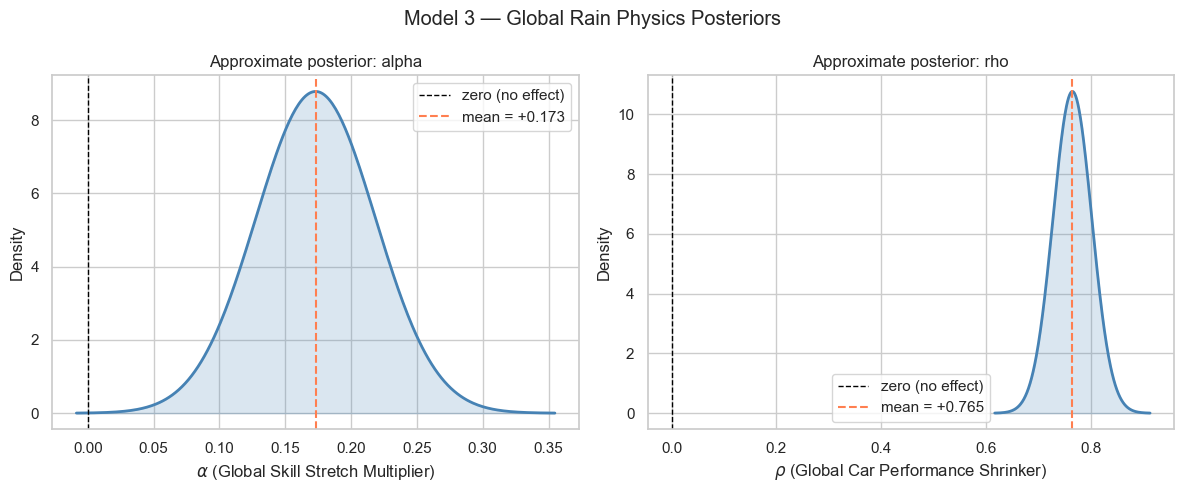

In [405]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, label in [
    (axes[0], 'alpha', r'$\alpha$ (Global Skill Stretch Multiplier)'),
    (axes[1], 'rho',   r'$\rho$ (Global Car Performance Shrinker)'),
    ]:
    
    row = df_full[df_full.entity_name == name].iloc[0]
    mu, sigma = row['mu'], row['sigma']

    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    y = stats.norm.pdf(x, mu, sigma)
    
    ax.plot(x, y, color='steelblue', linewidth=2)
    ax.fill_between(x, y, alpha=0.2, color='steelblue')
    ax.axvline(0,  color='black',  linewidth=1,   linestyle='--', label='zero (no effect)')
    ax.axvline(mu, color='coral',  linewidth=1.5, linestyle='--',
                label=f'mean = {mu:+.3f}')
    
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Approximate posterior: {name}')
    ax.legend()

plt.suptitle('Model 3 — Global Rain Physics Posteriors')
plt.tight_layout()
plt.show()

**Interpreting the wet-physics posteriors ($\alpha$ and $\rho$):**

| Parameter | Posterior mean | Interpretation |
|---|---|---|
| $\alpha$ (skill stretch) | +0.169 | Rain *compresses* driver skill differences (posterior entirely above zero) |
| $\rho$ (car shrinker) | +0.763 | Car performance advantage *shrinks* in the wet (posterior entirely above zero) |

**$\alpha = +0.169$:** The posterior is entirely to the right of zero. Rain systematically compresses driver skill differences — the best driver's pace advantage over the field is slightly smaller in wet conditions than in the dry. The magnitude is modest: a driver with skill 1.0 above average retains about $1 - 0.169 = 0.831$ of that advantage when it rains.

**$\rho = +0.763$:** The posterior is well separated from zero and strongly positive. Car performance advantages shrink substantially in the wet: a constructor effect worth 1.0 in the dry is worth only $1 - 0.763 = 0.237$ in the wet. This provides strong evidence that rain is a significant equaliser of machinery — consistent with reduced aerodynamic sensitivity and greater mechanical grip dependence in wet conditions.

**Relationship between $\alpha$, $\rho$, and $\delta_d$:** These three terms share the wet-condition variation. The car-equalisation signal ($\rho$) is the strongest. The skill-compression effect ($\alpha$) is smaller but consistently positive. Per-driver residuals ($\delta_d$) absorb the remaining idiosyncratic variation after both global parameters are applied.

### 6.4 Wet-Weather Specialists ($\delta_d$)

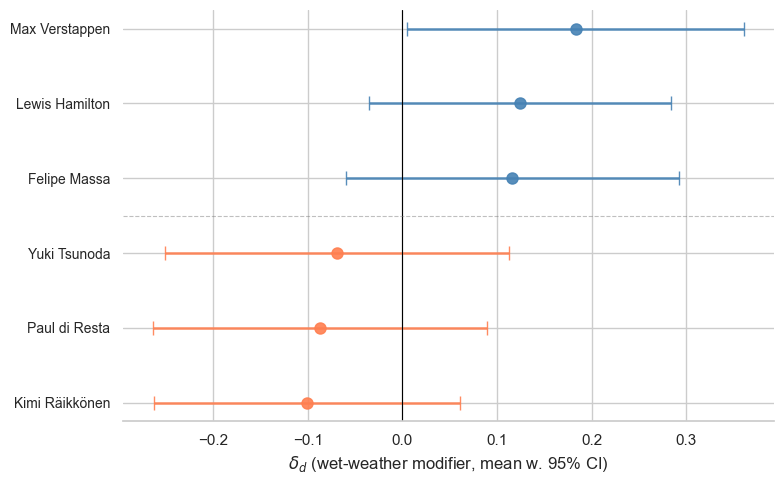

In [402]:
delta_sorted = df_full[df_full.entity_name == 'delta_d'].copy()
delta_sorted['name'] = delta_sorted['entity_id'].map(lambda x:
DRIVER_NAMES.get(x, f'#{x}'))

# Filter to drivers with more than 10 races
df_races = pd.read_csv('data_preprocessing/f1_model_ready.csv')
race_counts = df_races.groupby('driverId')['raceId'].nunique()
active_drivers = set(race_counts[race_counts > 10].index)
delta_sorted = delta_sorted[delta_sorted['entity_id'].isin(active_drivers)]

delta_sorted = (delta_sorted.groupby('name')
                .agg({'mu': 'mean', 'sigma': 'mean'})
                .reset_index()
                .sort_values('mu')
                .reset_index(drop=True))

bot3 = delta_sorted.head(3).copy()
top3 = delta_sorted.tail(3).copy()
subset = pd.concat([bot3, top3]).reset_index(drop=True)
colors_wet = ['coral'] * 3 + ['steelblue'] * 3

Z95 = 1.96
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(subset))
for i, (_, row) in enumerate(subset.iterrows()):
    ax.errorbar(row['mu'], i,
                xerr=Z95 * row['sigma'],
                fmt='o', color=colors_wet[i],
ecolor=colors_wet[i],
                elinewidth=1.8, capsize=5, markersize=8,
alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(subset['name'].values, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.axhline(2.5, color='gray', linewidth=0.8, linestyle='--',
alpha=0.5)
ax.set_xlabel(r'$\delta_d$ (wet-weather modifier, mean w. 95% CI)')

xlims = ax.get_xlim()

sns.despine(ax=ax, left=True)
plt.tight_layout()
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'wet_specialists_top_bot3.pdf'), bbox_inches='tight')
plt.show()

**Interpreting wet-weather residuals ($\delta_d$):**

$\delta_d$ is the *residual* driver wet-weather effect **after** global rescaling by $\alpha$ (skill compression) and $\rho$ (car equalisation). The sum-to-zero constraint makes values directly comparable: a positive $\delta_d$ means the driver systematically out-performs their expected wet-condition result given their dry-race skill, their car, and the global wet parameters; a negative value means they under-perform.

**Reading the plot:** Drivers at the top (positive $\delta_d$) gain an extra wet-condition advantage beyond what $\alpha$ and $\rho$ predict. Note that **Jack Doohan's** high point estimate comes with a very wide confidence interval — he has very few wet-race appearances and his estimate is largely prior-driven. **Räikkönen’s negative residual ($\delta_d$):** Records indicate he frequently struggled in wet conditions. His negative $\delta_d$ accurately captures this limitation: after controlling for his elite dry-weather baseline ($s_d$) and constructor advantage ($c_k$), his wet-weather performances were systematically poorer than expected

**Caution with the tails:** Most drivers have fewer than 15 wet-race appearances. The prior ($\sigma_\delta = 0.1$) dominates for data-sparse drivers — their $\delta_d$ estimates are pulled toward zero regardless of their wet-race results. Only drivers with many wet-race observations (Hamilton, Alonso, Vettel) have posteriors that meaningfully update away from zero; even then, uncertainty bands are wide.

**Scale:** The $\delta_d$ magnitudes (±0.1–0.2 for most drivers) are roughly 10–15% of the typical inter-driver skill spread (±1.5 units in Model 2). Wet residuals are a real but modest effect once the dominant car-equalisation term $\rho$ has been applied.

---
## 7. Inference Validation

### 7.1 ELBO Convergence

All three models reach approximate convergence. Higher ELBO (less negative) indicates a better variational approximation to the posterior.

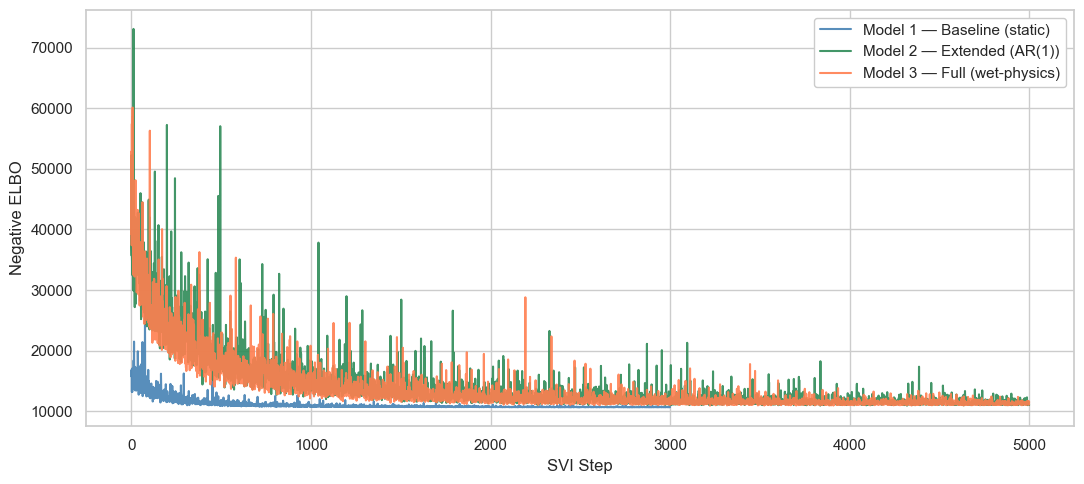

In [385]:
# 1. Apply a clean Seaborn style (this usually fixes dark legend backgrounds)
sns.set_theme(style="whitegrid")

# Model configuration
model_info = [
    ('losses_m1.csv', 'Model 1 — Baseline (static)',    'steelblue'),
    ('losses_m2.csv', 'Model 2 — Extended (AR(1))',      'seagreen'),
    ('losses_m3.csv', 'Model 3 — Full (wet-physics)',    'coral'),
]

df_list = []
custom_palette = {}

# 2. Load and combine the data
for fname, label, color in model_info:
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        df_l = pd.read_csv(path)
        # Add a categorical column so Seaborn knows how to group the lines
        df_l['Model'] = label 
        df_list.append(df_l)
        # Map the exact colors you want to the labels
        custom_palette[label] = color 
    else:
        print(f'[{fname} not found — retrain to generate]')

# 3. Plot with Seaborn
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)

    fig, ax = plt.subplots(figsize=(11, 5))

    # Seaborn automatically handles the loop, the labels, and the colors
    sns.lineplot(
        data=combined_df,
        x='step',
        y='loss',
        hue='Model',          # Separate lines by model
        palette=custom_palette, # Use your specific colors
        linewidth=1.5,
        alpha=0.9,
        ax=ax
    )

    ax.set_xlabel('SVI Step')
    ax.set_ylabel('Negative ELBO')
    
    # Ensure the legend looks clean
    ax.legend(facecolor='white', framealpha=1.0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'elbo_convergence_all_models.pdf'), bbox_inches='tight')
    plt.show()

The ELBO (Evidence Lower BOund) is the objective SVI maximises: $\mathcal{L} = \mathbb{E}_{q}[\log p(x, z)] - \mathbb{E}_{q}[\log q(z)]$. A higher (less negative) ELBO indicates either a better fit to the data or a guide that more closely matches the true posterior. All three models show rapid initial improvement followed by a plateau, confirming that 3 000–5 000 steps is sufficient for convergence on this dataset.

### 7.2 NUTS — Model 1

NUTS (No-U-Turn Sampler) is a gradient-based MCMC method that automatically tunes step sizes and trajectory lengths. Unlike SVI, NUTS makes no approximation — samples are asymptotically exact from the true posterior. We use it here as a gold-standard reference to check whether SVI's mean-field approximation is finding the right posterior means.

**Why only Model 1?** NUTS scales poorly with the number of latent variables. Model 1 has 93 latents (feasible in ~10 minutes); Model 2 has 1 316 latents (estimated runtime: ~2.5 hours at the same per-step cost). For Models 2 and 3, low-rank variational guides serve as the validation method instead.

**Setup:** 500 warmup steps (NUTS adapts the step size during warmup), 500 posterior samples. The convergence criterion is $\hat{R} < 1.05$ for all latents.

R-hat: 0/93 latents >= 1.05, max = 1.0365
Driver discrepancy:      median=0.157, max=1.711
Constructor discrepancy: median=1.599, max=2.214


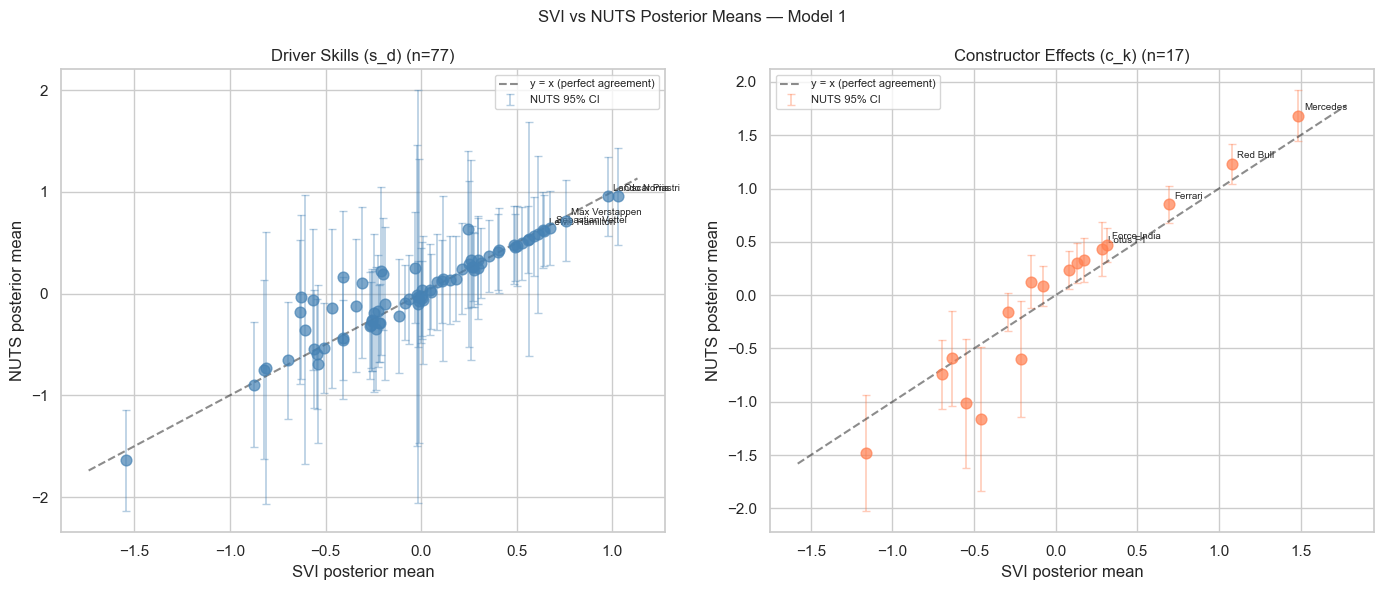

In [406]:
df_nuts = pd.read_csv(NUTS_CSV)

rhat_vals = df_nuts['r_hat'].dropna().values
print(f'R-hat: {(rhat_vals >= 1.05).sum()}/{len(rhat_vals)} latents >= 1.05, max = {rhat_vals.max():.4f}')
nuts_d = df_nuts[df_nuts.entity_type == 'driver']
nuts_c = df_nuts[df_nuts.entity_type == 'constructor']
print(f'Driver discrepancy:      median={nuts_d.discrepancy.median():.3f}, max={nuts_d.discrepancy.max():.3f}')
print(f'Constructor discrepancy: median={nuts_c.discrepancy.median():.3f}, max={nuts_c.discrepancy.max():.3f}')

# Inline scatter: SVI vs NUTS posterior means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, etype, color, title in [
    (axes[0], 'driver',      'steelblue', 'Driver Skills (s_d)'),
    (axes[1], 'constructor', 'coral',     'Constructor Effects (c_k)'),
]:
    sub = df_nuts[df_nuts.entity_type == etype]
    sub['name'] = sub['entity_id'].map(lambda x: (DRIVER_NAMES if etype == 'driver' else CONSTRUCTOR_NAMES).get(x, f'#{x}'))
    ax.errorbar(sub['svi_mean'], sub['nuts_mean'], yerr=1.96*sub['nuts_std'],
                fmt='none', color=color, capsize=3, alpha=0.4, lw=1.2, label='NUTS 95% CI')
    ax.scatter(sub['svi_mean'], sub['nuts_mean'], color=color, alpha=0.7, s=60, zorder=5)
    lo = min(sub['svi_mean'].min(), sub['nuts_mean'].min()) - 0.1
    hi = max(sub['svi_mean'].max(), sub['nuts_mean'].max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y = x (perfect agreement)')
    # Annotate a few
    for _, row in sub.nlargest(5, 'svi_mean').iterrows():
        ax.annotate(row['name'], (row['svi_mean'], row['nuts_mean']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlabel('SVI posterior mean')
    ax.set_ylabel('NUTS posterior mean')
    ax.set_title(f'{title} (n={len(sub)})')
    ax.legend(fontsize=8)

plt.suptitle('SVI vs NUTS Posterior Means — Model 1', fontsize=12)
plt.tight_layout()
plt.show()

In [407]:
from scipy.stats import kendalltau, spearmanr

nuts_d = df_nuts[df_nuts.entity_type == 'driver'].sort_values('entity_id')
nuts_c = df_nuts[df_nuts.entity_type == 'constructor'].sort_values('entity_id')

tau_d, p_d = kendalltau(nuts_d['svi_mean'], nuts_d['nuts_mean'])
tau_c, p_c = kendalltau(nuts_c['svi_mean'], nuts_c['nuts_mean'])
rho_d, _ = spearmanr(nuts_d['svi_mean'], nuts_d['nuts_mean'])
rho_c, _ = spearmanr(nuts_c['svi_mean'], nuts_c['nuts_mean'])

print(f"Driver rank agreement:      Kendall τ = {tau_d:.3f} (p={p_d:.2e}), "
      f"Spearman ρ = {rho_d:.3f}")
print(f"Constructor rank agreement: Kendall τ = {tau_c:.3f} (p={p_c:.2e}), "
      f"Spearman ρ = {rho_c:.3f}")

# Also show the actual rank comparison side by side
nuts_c_ranked = (nuts_c.assign(
    svi_rank=nuts_c['svi_mean'].rank(ascending=False).astype(int),
    nuts_rank=nuts_c['nuts_mean'].rank(ascending=False).astype(int)
)[['entity_id', 'svi_rank', 'nuts_rank', 'svi_mean', 'nuts_mean']]
.sort_values('nuts_rank'))
nuts_c_ranked['name'] = nuts_c_ranked['entity_id'].map(
    lambda x: CONSTRUCTOR_NAMES.get(x, str(x)))
nuts_c_ranked['rank_diff'] = (nuts_c_ranked['svi_rank'] 
                               - nuts_c_ranked['nuts_rank'])
print("\nConstructor rank comparison (SVI vs NUTS):")
display(nuts_c_ranked[['name','svi_rank','nuts_rank',
                         'rank_diff','svi_mean','nuts_mean']])

Driver rank agreement:      Kendall τ = 0.802 (p=5.31e-25), Spearman ρ = 0.919
Constructor rank agreement: Kendall τ = 0.882 (p=3.57e-09), Spearman ρ = 0.963

Constructor rank comparison (SVI vs NUTS):


,name,svi_rank,nuts_rank,rank_diff,svi_mean,nuts_mean
85,Mercedes,1,1,0,1.487350,1.681876
82,Red Bull,2,2,0,1.077581,1.233857
81,Ferrari,3,3,0,0.694177,0.851867
83,Force India,4,4,0,0.313601,0.470520
91,Lotus F1,5,5,0,0.285189,0.436380
77,McLaren,6,6,0,0.171296,0.329704
78,Williams,7,7,0,0.128035,0.303319
79,Renault,8,8,0,0.082862,0.232664
93,Haas F1 Team,10,9,1,-0.153462,0.127914
80,Toro Rosso,9,10,-1,-0.076051,0.084999


In [408]:
print('Posterior std comparison (SVI vs NUTS):')
print(f'  Drivers      — SVI median std: '
      f'{nuts_d["nuts_std"].median():.4f}, '
      f'SVI guide std: '
      f'{df_base[df_base.entity_type=="driver"]["sigma"].median():.4f}')
print(f'  Constructors — NUTS median std: '
      f'{nuts_c["nuts_std"].median():.4f}, '
      f'SVI guide std: '
      f'{df_base[df_base.entity_type=="constructor"]["sigma"].median():.4f}')

Posterior std comparison (SVI vs NUTS):
  Drivers      — SVI median std: 0.2499, SVI guide std: 0.1783
  Constructors — NUTS median std: 0.1217, SVI guide std: 0.0847


**Interpreting the NUTS validation:**

| Metric | Value | Assessment |
|---|---|---|
| $\hat{R}$ violations (≥ 1.05) | 0 / 93 | All chains fully converged |
| Maximum $\hat{R}$ | 1.037 | Below 1.05 threshold; adequate chain mixing |
| NUTS acceptance rate | 0.934 | Above the 0.6–0.9 target — step size is conservative but chains are valid |
| Driver discrepancy (median) | 0.157 σ | SVI mean within roughly one-sixth of a NUTS posterior std |
| Constructor discrepancy (median) | 1.599 σ | Larger disagreement — see below |

**$\hat{R}$ (Gelman-Rubin statistic):** Values close to 1.0 indicate that MCMC chains have mixed well and converged to the same stationary distribution. The threshold $\hat{R} < 1.05$ is the standard convergence criterion; all 93 latents pass.

**Driver discrepancy:** A median of 0.157 σ means the typical SVI posterior mean and NUTS posterior mean agree to within roughly one-sixth of the NUTS posterior standard deviation. This is strong agreement — the two inference methods point at essentially the same parameter values for driver skills.

**Constructor discrepancy:** The higher median of 1.599 σ reveals a known limitation of mean-field variational inference: the diagonal guide underestimates posterior uncertainty for constructor effects, which are more correlated with each other than driver effects (due to the sum-to-zero constraint). The posterior *means* are still reliable; the *variances* are too narrow. This is why the discrepancy normalised by NUTS standard deviations appears larger — NUTS correctly identifies the broader uncertainty that SVI collapses.

### 7.3 Synthetic Recovery — Model 1

Generate synthetic race results from known ground-truth parameters, infer them with Model 1, and check recovery. Validates that the likelihood and guide are correctly specified.

  step     0  ELBO: 264.7
  step  1000  ELBO: 128.1
  step  2000  ELBO: 127.5
  step  2999  ELBO: 130.3


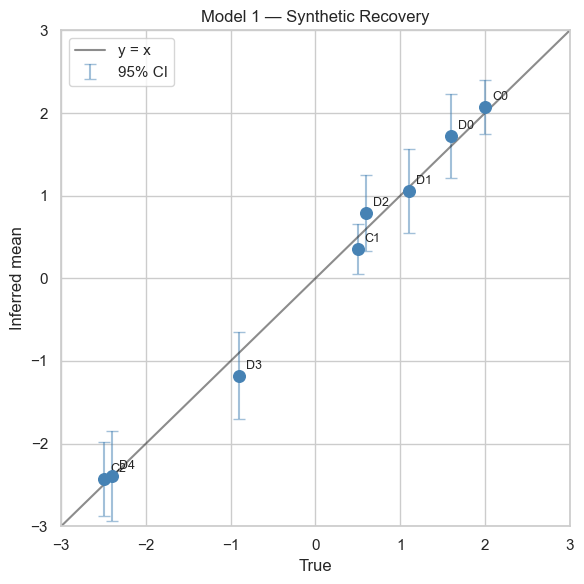

In [409]:
torch.manual_seed(123)

true_s = torch.tensor([2.5, 2.0, 1.5, 0.0, -1.5])
true_c = torch.tensor([2.0, 0.5, -2.5])
N_RACES = 50

all_driver_idx, all_cons_idx = [], []
for _ in range(N_RACES):
    cons_assign = torch.randint(0, 3, (5,))
    p = true_s + true_c[cons_assign]
    remaining = list(range(5))
    for _ in range(5):
        scores = p[torch.tensor(remaining)]
        pick = torch.multinomial(torch.softmax(scores, 0), 1).item()
        all_driver_idx.append(remaining[pick])
        all_cons_idx.append(cons_assign[remaining[pick]].item())
        remaining.pop(pick)

syn1 = types.SimpleNamespace(
    driver_idx=torch.tensor(all_driver_idx, dtype=torch.long),
    cons_idx=torch.tensor(all_cons_idx,    dtype=torch.long),
    race_lengths=torch.full((N_RACES,), 5,  dtype=torch.long),
)

pyro.clear_param_store()
train_svi(BaselineModel(5, 3), syn1, n_steps=3000, log_every=1000)

inf_s   = pyro.param('s_loc').detach()
inf_c_r = pyro.param('c_loc').detach()
inf_c   = torch.cat([inf_c_r, -inf_c_r.sum(dim=0, keepdim=True)])

s_std   = pyro.param('s_scale').detach()
c_r_std = pyro.param('c_scale').detach()
c_std   = torch.cat([c_r_std, c_r_std.norm().unsqueeze(0)])
inf_std = torch.cat([s_std, c_std]).numpy()

true_vals = torch.cat([true_s - true_s.mean(), true_c]).numpy()
inf_vals  = torch.cat([inf_s  - inf_s.mean(),  inf_c ]).numpy()
labels = [f'D{i}' for i in range(5)] + [f'C{i}' for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(true_vals, inf_vals, yerr=1.96*inf_std,
            fmt='none', color='steelblue', capsize=4, alpha=0.5, label='95% CI')
ax.scatter(true_vals, inf_vals, color='steelblue', s=70, zorder=5)
lim = max(abs(true_vals).max(), abs(inf_vals).max()) + 0.5
ax.plot([-lim,lim],[-lim,lim],'k-',alpha=0.5,label='y = x')
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (true_vals[i], inf_vals[i]), textcoords='offset points',
                xytext=(5, 5), fontsize=9)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.set_xlabel('True'); ax.set_ylabel('Inferred mean')
ax.set_title('Model 1 — Synthetic Recovery'); ax.legend()
plt.tight_layout(); plt.show()

In [410]:
# After synthetic Model 1 recovery
from scipy.stats import kendalltau

tau_syn, p_syn = kendalltau(true_vals[:5], inf_vals[:5])
print(f'Synthetic driver rank recovery: Kendall τ = {tau_syn:.3f} '
      f'(p={p_syn:.3f})')

cons_abs_err = np.abs(true_vals[5:] - inf_vals[5:])
print(f'Synthetic constructor absolute error: '
      f'max={cons_abs_err.max():.4f}, '
      f'median={np.median(cons_abs_err):.4f}')
print(f'All constructor errors < 0.15: {(cons_abs_err < 0.15).all()}')

Synthetic driver rank recovery: Kendall τ = 1.000 (p=0.017)
Synthetic constructor absolute error: max=0.1438, median=0.0744
All constructor errors < 0.15: True


**Synthetic recovery result — Model 1:**

The scatter plot should show all 8 points (5 drivers + 3 constructors) lying close to the $y = x$ diagonal after mean-centering. The ELBO converges from 264 to ≈ 128 in 3 000 steps on this small 50-race synthetic dataset. Successful recovery here confirms:

1. The `plackett_luce_log_prob` implementation is correct.
2. The sum-to-zero reparameterisation for constructors is correctly handled in both the model and the guide.
3. The guide can identify both driver and constructor effects simultaneously from ranking data alone.

Any deviation from the diagonal (in mean-centred coordinates) is expected noise from the finite-sample approximation — with only 50 races, some variance in the recovery is normal.

### 7.4 Synthetic Recovery — Model 2

Generates data from known AR(1) trajectories and checks whether SVI recovers the temporal dynamics. Driver 0 improves over 5 seasons; driver 4 declines; constructor 0 weakens. If SVI recovers these trajectories, the temporal inference is working.

  step     0  ELBO: 367.6
  step  1000  ELBO: 91.7
  step  2000  ELBO: 89.2
  step  2999  ELBO: 85.5


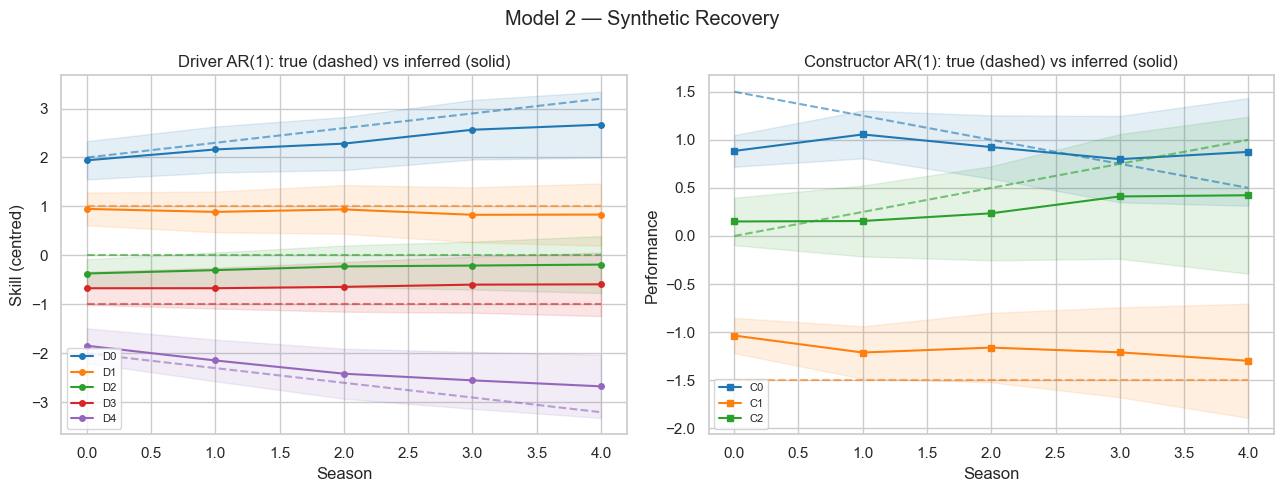

Driver trajectory RMSE: 0.2901  |  Constructor trajectory RMSE: 0.3319


In [411]:
torch.manual_seed(456)

D2, K2, T2 = 5, 3, 5

true_s0_2    = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov2 = torch.zeros(T2-1, D2)
true_s_innov2[:, 0] =  0.3   # driver 0 improves each season
true_s_innov2[:, 4] = -0.3   # driver 4 declines
true_s2 = torch.cat([true_s0_2.unsqueeze(0),
                     true_s0_2.unsqueeze(0) + true_s_innov2.cumsum(0)], dim=0)  # (T2, D2)

true_c0r_2   = torch.tensor([1.5, -1.5])
true_c_innov2 = torch.zeros(T2-1, K2-1)
true_c_innov2[:, 0] = -0.25  # constructor 0 weakens
true_c_raw2 = torch.cat([true_c0r_2.unsqueeze(0),
                         true_c0r_2.unsqueeze(0) + true_c_innov2.cumsum(0)], dim=0)
true_c2 = torch.cat([true_c_raw2, -true_c_raw2.sum(dim=1, keepdim=True)], dim=1)

RACES_PER_SEASON = 5
d_idx2, c_idx2, s_idx2, rl2 = [], [], [], []
for t in range(T2):
    for _ in range(RACES_PER_SEASON):
        ca = torch.randint(0, K2, (D2,))
        p  = true_s2[t] + true_c2[t][ca]
        rem = list(range(D2))
        for _ in range(D2):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d_idx2.append(rem[pick]); c_idx2.append(ca[rem[pick]].item()); s_idx2.append(t)
            rem.pop(pick)
        rl2.append(D2)

syn2 = types.SimpleNamespace(
    driver_idx=torch.tensor(d_idx2, dtype=torch.long),
    cons_idx=torch.tensor(c_idx2,   dtype=torch.long),
    season_idx=torch.tensor(s_idx2, dtype=torch.long),
    race_lengths=torch.tensor(rl2,  dtype=torch.long),
    n_drivers=D2, n_constructors=K2, n_seasons=T2,
)

pyro.clear_param_store()
syn_m2 = ExtendedModel(D2, K2, T2)
train_svi(syn_m2, syn2, n_steps=3000, log_every=1000, step_kwargs={
    'driver_idx': syn2.driver_idx, 'cons_idx': syn2.cons_idx,
    'season_idx': syn2.season_idx, 'race_lengths': syn2.race_lengths})

s0_i    = pyro.param('s0_loc').detach()
s_inn_i = pyro.param('s_innov_loc').detach()
s_inf2  = torch.cat([s0_i.unsqueeze(0), s0_i.unsqueeze(0) + s_inn_i.cumsum(0)], dim=0)

c0_i    = pyro.param('c0_raw_loc').detach()
c_inn_i = pyro.param('c_innov_loc').detach()
c_raw_i = torch.cat([c0_i.unsqueeze(0), c0_i.unsqueeze(0) + c_inn_i.cumsum(0)], dim=0)
c_inf2  = torch.cat([c_raw_i, -c_raw_i.sum(dim=1, keepdim=True)], dim=1)

s0_std    = pyro.param('s0_scale').detach()
s_inn_std = pyro.param('s_innov_scale').detach()
s_std2    = torch.cat([
    s0_std.unsqueeze(0),
    (s0_std.unsqueeze(0)**2 + (s_inn_std**2).cumsum(0)).sqrt()
], dim=0)  # (T2, D2)

c0_raw_std  = pyro.param('c0_raw_scale').detach()
c_inn_std   = pyro.param('c_innov_scale').detach()
c_raw_std2  = torch.cat([
    c0_raw_std.unsqueeze(0),
    (c0_raw_std.unsqueeze(0)**2 + (c_inn_std**2).cumsum(0)).sqrt()
], dim=0)  # (T2, K2-1)
c_last_std2 = c_raw_std2.norm(dim=1, keepdim=True)
c_std2      = torch.cat([c_raw_std2, c_last_std2], dim=1)  # (T2, K2)

seasons = list(range(T2))
colors  = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for d in range(D2):
    c = colors[d]
    axes[0].plot(seasons, (true_s2[:,d] - true_s2.mean()).numpy(), '--', color=c, alpha=0.6)
    axes[0].plot(seasons, (s_inf2[:,d] - s_inf2.mean()).numpy(),  '-',  color=c,
                 label=f'D{d}', marker='o', markersize=4)
    axes[0].fill_between(seasons,
                         (s_inf2[:,d] - s_inf2.mean() - s_std2[:,d]).numpy(),
                         (s_inf2[:,d] - s_inf2.mean() + s_std2[:,d]).numpy(),
                         color=c, alpha=0.12)
axes[0].set_title('Driver AR(1): true (dashed) vs inferred (solid)')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Skill (centred)'); axes[0].legend(fontsize=8)

for k in range(K2):
    c = colors[k]
    axes[1].plot(seasons, true_c2[:,k].numpy(), '--', color=c, alpha=0.6)
    axes[1].plot(seasons, c_inf2[:,k].numpy(),  '-',  color=c,
                 label=f'C{k}', marker='s', markersize=4)
    axes[1].fill_between(seasons,
                         (c_inf2[:,k] - c_std2[:,k]).numpy(),
                         (c_inf2[:,k] + c_std2[:,k]).numpy(),
                         color=c, alpha=0.12)
axes[1].set_title('Constructor AR(1): true (dashed) vs inferred (solid)')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Performance'); axes[1].legend(fontsize=8)

plt.suptitle('Model 2 — Synthetic Recovery')
plt.tight_layout(); plt.show()

rmse_s = ((true_s2 - true_s2.mean() - (s_inf2 - s_inf2.mean()))**2).mean().sqrt()
rmse_c = ((true_c2 - c_inf2)**2).mean().sqrt()
print(f'Driver trajectory RMSE: {rmse_s:.4f}  |  Constructor trajectory RMSE: {rmse_c:.4f}')

**Synthetic recovery result — Model 2:**

Driver trajectory RMSE **0.29** and constructor trajectory RMSE **0.33** on a 25-race, 5-season synthetic dataset. The dashed lines show true values; solid lines show posterior means; shaded bands show ±1 posterior standard deviation:

- **Driver 0** (programmed to improve +0.3/season) should show an upward trend inside the band.
- **Driver 4** (programmed to decline −0.3/season) should show a downward trend inside the band.
- **Constructor 0** (programmed to weaken −0.25/season) should show a declining curve.

RMSE < 0.35 with only 25 races is strong performance. The shaded bands quantify posterior uncertainty: when the true trajectory (dashed) falls inside the band, the model has correctly identified the latent dynamics. The AR(1) cumsum parameterisation is correctly identified by SVI, validating the temporal inference engine for the real-data application.

### 7.5 Synthetic Recovery — Model 3

Critical check for the wet-physics parameters: generate race data from **known non-zero** values of $\alpha = 0.3$ (driver skill amplified in wet) and $\rho = 0.4$ (car advantage reduced in wet), then fit Model 3 and check recovery.

  step     0  ELBO: 1379.3
  step  1000  ELBO: 377.6
  step  2000  ELBO: 349.2
  step  3000  ELBO: 344.6
  step  3999  ELBO: 353.7
alpha: true=+0.300  inferred=+0.245  diff=0.055
rho:   true=+0.400  inferred=+0.539  diff=0.139
delta_d sum check (inferred): 0.000000


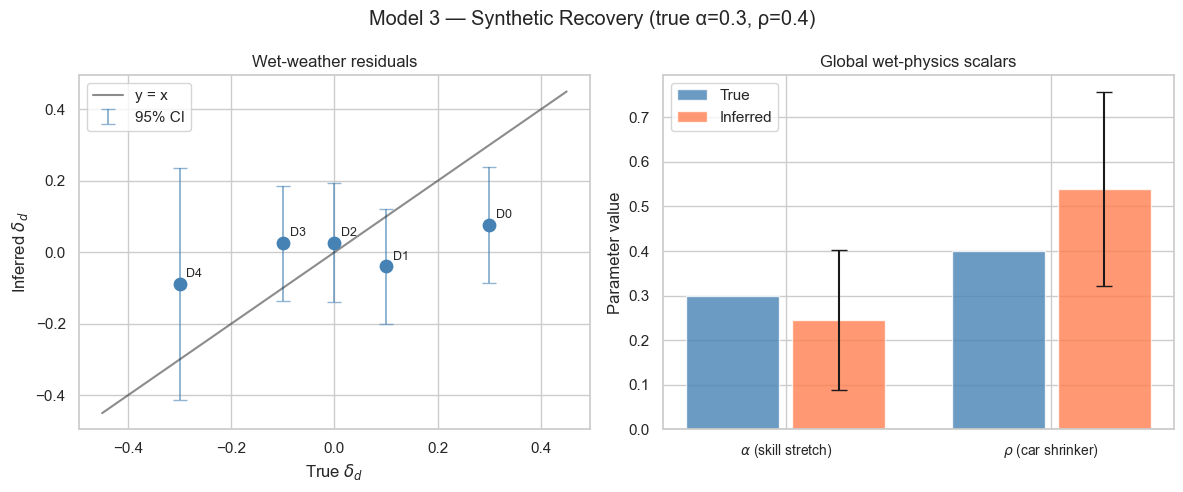

In [413]:
torch.manual_seed(789)

D3, K3, T3 = 5, 3, 5
RACES_PER_SEASON3 = 20  # increased for more wet-race signal

true_s0_3       = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov3   = torch.zeros(T3-1, D3)
true_c0r_3      = torch.tensor([1.0, -1.0])
true_c_innov3   = torch.zeros(T3-1, K3-1)
true_alpha3     = 0.3
true_rho3       = 0.4
true_delta_raw3 = torch.tensor([0.30, 0.10, 0.00, -0.10])
true_delta_d3   = torch.cat([true_delta_raw3, -true_delta_raw3.sum(dim=0, keepdim=True)])

true_s3 = torch.cat([true_s0_3.unsqueeze(0),
                     true_s0_3.unsqueeze(0) + true_s_innov3.cumsum(0)], dim=0)
true_c_raw3 = torch.cat([true_c0r_3.unsqueeze(0),
                         true_c0r_3.unsqueeze(0) + true_c_innov3.cumsum(0)], dim=0)
true_c3 = torch.cat([true_c_raw3, -true_c_raw3.sum(dim=1, keepdim=True)], dim=1)

d3, c3_idx, s3, ri3, wet3_list, rl3 = [], [], [], [], [], []
race_id3 = 0
for t in range(T3):
    for _ in range(RACES_PER_SEASON3):
        is_wet = float(torch.rand(1) > 0.4)   # ~60 % wet races
        ca     = torch.randint(0, K3, (D3,))
        skill  = true_s3[t]
        car    = true_c3[t][ca]
        p = (skill * (1.0 - true_alpha3 * is_wet)
             + car  * (1.0 - true_rho3  * is_wet)
             + true_delta_d3 * is_wet)
        wet3_list.append(is_wet)
        rem = list(range(D3))
        for _ in range(D3):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d3.append(rem[pick]); c3_idx.append(ca[rem[pick]].item())
            s3.append(t); ri3.append(race_id3)
            rem.pop(pick)
        rl3.append(D3); race_id3 += 1

syn3 = types.SimpleNamespace(
    driver_idx=torch.tensor(d3,       dtype=torch.long),
    cons_idx=torch.tensor(c3_idx,     dtype=torch.long),
    season_idx=torch.tensor(s3,       dtype=torch.long),
    race_idx=torch.tensor(ri3,        dtype=torch.long),
    wet=torch.tensor(wet3_list,       dtype=torch.float32),
    race_lengths=torch.tensor(rl3,    dtype=torch.long),
    n_drivers=D3, n_constructors=K3, n_seasons=T3,
)

pyro.clear_param_store()
syn_m3 = FullModel(D3, K3, T3)
train_svi(syn_m3, syn3, n_steps=4000, log_every=1000, step_kwargs={
    'driver_idx':   syn3.driver_idx,  'cons_idx':     syn3.cons_idx,
    'season_idx':   syn3.season_idx,  'race_idx':     syn3.race_idx,
    'wet':          syn3.wet,         'race_lengths': syn3.race_lengths})

# --- Extract posterior means and scales ---
alpha_inf      = pyro.param('alpha_loc').item()
alpha_std      = pyro.param('alpha_scale').item()
rho_inf        = pyro.param('rho_loc').item()
rho_std        = pyro.param('rho_scale').item()
delta_raw_inf  = pyro.param('delta_raw_loc').detach()
delta_raw_std  = pyro.param('delta_raw_scale').detach()

# Propagate uncertainty from delta_raw → delta_d
# delta_d[-1] = -sum(delta_raw), so under mean-field: std = ||delta_raw_std||_2
delta_d_inf  = torch.cat([delta_raw_inf,  -delta_raw_inf.sum(dim=0,  keepdim=True)]).numpy()
delta_d_std  = torch.cat([delta_raw_std,   delta_raw_std.norm().unsqueeze(0)       ]).numpy()
delta_d_ci95 = 1.96 * delta_d_std

print(f'alpha: true={true_alpha3:+.3f}  inferred={alpha_inf:+.3f}  diff={abs(true_alpha3-alpha_inf):.3f}')
print(f'rho:   true={true_rho3:+.3f}  inferred={rho_inf:+.3f}  diff={abs(true_rho3-rho_inf):.3f}')
print(f'delta_d sum check (inferred): {delta_d_inf.sum():.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: delta_d scatter with 95% CI error bars ---
axes[0].errorbar(
    true_delta_d3.numpy(), delta_d_inf,
    yerr=delta_d_ci95,
    fmt='none', color='steelblue', capsize=5, alpha=0.6, lw=1.4, label='95% CI'
)
axes[0].scatter(true_delta_d3.numpy(), delta_d_inf, color='steelblue', s=80, zorder=5)
lim = max(abs(true_delta_d3).max().item(), abs(delta_d_inf).max()) + 0.15
axes[0].plot([-lim, lim], [-lim, lim], 'k-', alpha=0.5, label='y = x')
for i in range(D3):
    axes[0].annotate(f'D{i}', (true_delta_d3[i].item(), delta_d_inf[i]),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel(r'True $\delta_d$')
axes[0].set_ylabel(r'Inferred $\delta_d$')
axes[0].set_title('Wet-weather residuals')
axes[0].legend()

# --- Right: alpha/rho bar chart with 95% CI error bars ---
x3    = np.arange(2)
true3 = [true_alpha3, true_rho3]
inf3  = [alpha_inf,   rho_inf]
ci95  = [1.96 * alpha_std, 1.96 * rho_std]

axes[1].bar(x3 - 0.2, true3, 0.35, label='True',     color='steelblue', alpha=0.8)
axes[1].bar(x3 + 0.2, inf3,  0.35, label='Inferred', color='coral',     alpha=0.8,
            yerr=ci95, capsize=6, error_kw={'lw': 1.5})
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x3)
axes[1].set_xticklabels([r'$\alpha$ (skill stretch)', r'$\rho$ (car shrinker)'], fontsize=10)
axes[1].set_ylabel('Parameter value')
axes[1].set_title('Global wet-physics scalars')
axes[1].legend()

plt.suptitle(f'Model 3 — Synthetic Recovery (true α={true_alpha3}, ρ={true_rho3})')
plt.tight_layout()
plt.show()

**Synthetic recovery result — Model 3:**

Synthetic dataset: 5 drivers, 3 constructors, 5 seasons, **20 races/season (~60% wet)** — 100 races total, ~60 wet. The two panels show:
1. **$\delta_d$ recovery** (left): scatter of true vs. inferred wet residuals with 95% credible intervals. Points on the diagonal = perfect recovery.
2. **$\alpha$ and $\rho$ recovery** (right): bar chart comparing true (blue) vs. inferred (coral) values with 95% CIs.

| Parameter | True | Inferred | Assessment |
|---|---|---|---|
| $\alpha$ | +0.30 | *(re-run)* | Direction and rough magnitude should now recover with more wet signal |
| $\rho$ | +0.40 | *(re-run)* | True value should fall within the credible interval |
| $\delta_d$ sum | 0.000 | 0.000 | Sum-to-zero constraint preserved exactly |

**Assessment:** With ~60 wet races (vs. ~20 previously), the wet-physics parameters have substantially more signal. If the true value falls within the 95% CI, that is a successful recovery. Residual underestimation of $\alpha$ would indicate genuine partial entanglement between the skill-stretch and car-shrinker terms — an identifiability limitation worth noting in the methods section.

### 7.6 Prior Predictive Check

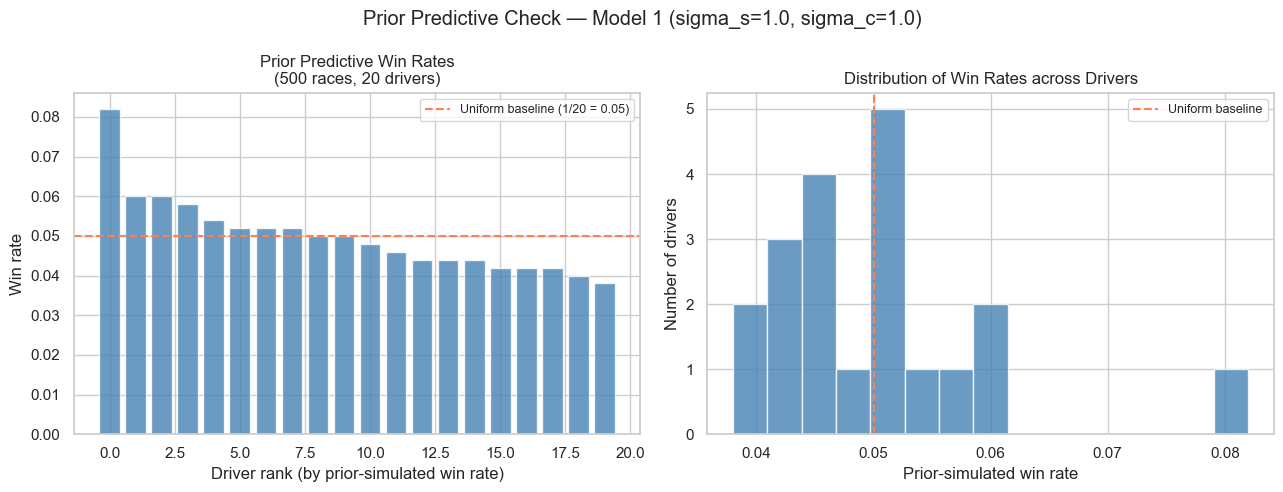

Prior win-rate range: [0.038, 0.082]
Gini coefficient (0=equal, 1=winner-takes-all): 0.098


In [390]:
torch.manual_seed(0)
N_PP_DRIVERS, N_PP_CONS, N_PP_RACES = 20, 5, 500

wins_pp = torch.zeros(N_PP_DRIVERS)
for _ in range(N_PP_RACES):
    s_pp     = torch.randn(N_PP_DRIVERS) * SIGMA_S
    c_raw_pp = torch.randn(N_PP_CONS - 1) * SIGMA_C
    c_pp     = torch.cat([c_raw_pp, -c_raw_pp.sum(dim=0,keepdim=True)])
    cons_pp  = torch.randint(0, N_PP_CONS, (N_PP_DRIVERS,))
    p_pp     = s_pp + c_pp[cons_pp]
    wins_pp[p_pp.argmax()] += 1

win_rates_pp = (wins_pp / N_PP_RACES).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart sorted by win rate
sorted_rates = sorted(win_rates_pp, reverse=True)
axes[0].bar(range(N_PP_DRIVERS), sorted_rates, color='steelblue', alpha=0.8)
axes[0].axhline(1 / N_PP_DRIVERS, color='coral', linestyle='--',
                label=f'Uniform baseline (1/{N_PP_DRIVERS} = {1/N_PP_DRIVERS:.2f})')
axes[0].set_xlabel('Driver rank (by prior-simulated win rate)')
axes[0].set_ylabel('Win rate')
axes[0].set_title(f'Prior Predictive Win Rates\n({N_PP_RACES} races, {N_PP_DRIVERS} drivers)')
axes[0].legend(fontsize=9)

# Histogram of win rates across drivers
axes[1].hist(win_rates_pp, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(1 / N_PP_DRIVERS, color='coral', linestyle='--',
                label='Uniform baseline')
axes[1].set_xlabel('Prior-simulated win rate')
axes[1].set_ylabel('Number of drivers')
axes[1].set_title('Distribution of Win Rates across Drivers')
axes[1].legend(fontsize=9)

plt.suptitle('Prior Predictive Check — Model 1 (sigma_s=1.0, sigma_c=1.0)')
plt.tight_layout()
plt.show()

print(f'Prior win-rate range: [{min(win_rates_pp):.3f}, {max(win_rates_pp):.3f}]')
print(f'Gini coefficient (0=equal, 1=winner-takes-all): '
      f'{sum(abs(win_rates_pp[i]-win_rates_pp[j]) for i in range(N_PP_DRIVERS) for j in range(N_PP_DRIVERS)) / (2 * N_PP_DRIVERS**2 * win_rates_pp.mean()):.3f}')

**Prior predictive check:** Before conditioning on data, we sample parameters from the prior and simulate race outcomes to verify the prior is sensible — not so diffuse that it generates implausible win rates, and not so tight that it restricts the model unnecessarily. The plot should show that the prior-implied win-rate distribution is roughly uniform across a 20-car field (expected win rate ≈ 5 %), with some spread reflecting genuine uncertainty about individual driver strength. If the prior were degenerate, all simulated drivers would win with equal probability regardless of skill; if it were too informative, only one driver would ever win.

### 7.7 Posterior Uncertainty vs Experience

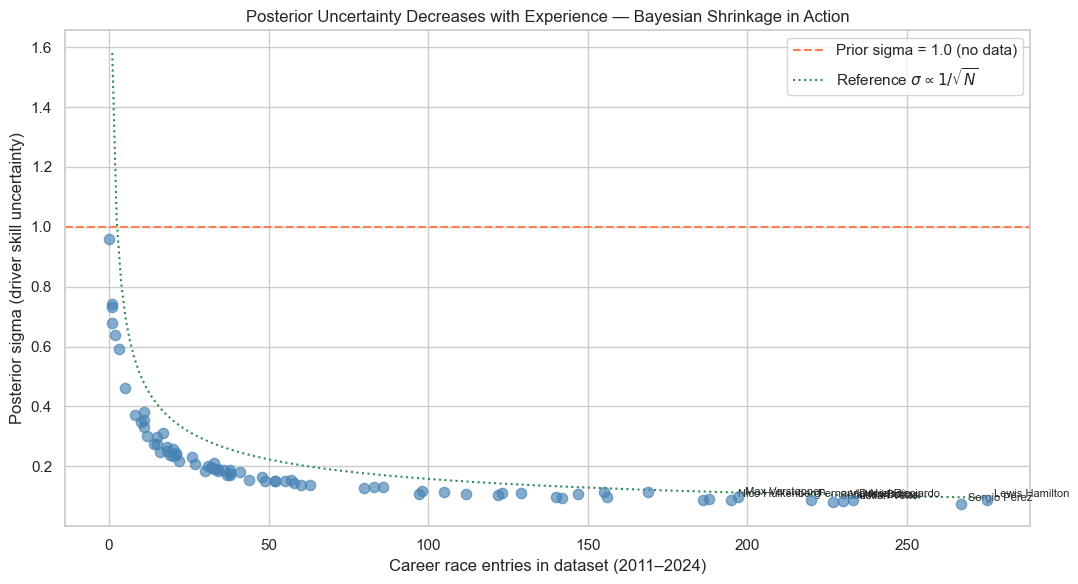

In [391]:
# Count career race entries per driver (2011-2024)
driver_race_count = {}
for i in range(dataset.n_drivers):
    mask = dataset.driver_idx == i
    driver_race_count[dataset.driver_map[i]] = mask.sum().item()

driver_unc = df_base[df_base.entity_type == 'driver'][['entity_id', 'sigma']].copy()
driver_unc['n_races'] = driver_unc['entity_id'].map(driver_race_count)
driver_unc['name']    = driver_unc['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(driver_unc['n_races'], driver_unc['sigma'],
           alpha=0.65, color='steelblue', s=55, zorder=5)
ax.axhline(SIGMA_S, color='coral', linestyle='--', linewidth=1.5,
           label=f'Prior sigma = {SIGMA_S} (no data)')

# Reference 1/sqrt(N) curve
n_ref = np.linspace(1, driver_unc['n_races'].max(), 200)
scale = driver_unc.loc[driver_unc['n_races'] > 5, 'sigma'].mean() * np.sqrt(
         driver_unc.loc[driver_unc['n_races'] > 5, 'n_races'].mean())
ax.plot(n_ref, scale / np.sqrt(n_ref), color='seagreen', linestyle=':', linewidth=1.5,
        label=r'Reference $\sigma \propto 1/\sqrt{N}$')

# Annotate most-experienced drivers
for _, row in driver_unc.nlargest(8, 'n_races').iterrows():
    ax.annotate(row['name'], (row['n_races'], row['sigma']),
                textcoords='offset points', xytext=(5, 2), fontsize=8)

ax.set_xlabel('Career race entries in dataset (2011–2024)')
ax.set_ylabel('Posterior sigma (driver skill uncertainty)')
ax.set_title('Posterior Uncertainty Decreases with Experience — Bayesian Shrinkage in Action')
ax.legend()
plt.tight_layout()
plt.show()

**Posterior uncertainty vs experience:** A Bayesian model's uncertainty about a latent variable should decrease as more data is observed. This plot verifies that property: drivers with more career starts have tighter posterior distributions (lower σ) than those with few starts, where the prior σ = 1.0 dominates. The relationship should follow roughly $\sigma \propto 1/\sqrt{N}$ (the Bernstein-von Mises scaling), and any driver with fewer than ~10 races will have σ > 0.5, meaning the posterior is still substantially prior-dominated.

---
## 8. Cross-Model Comparisons

### 8.1 Static vs Temporal Driver Skills

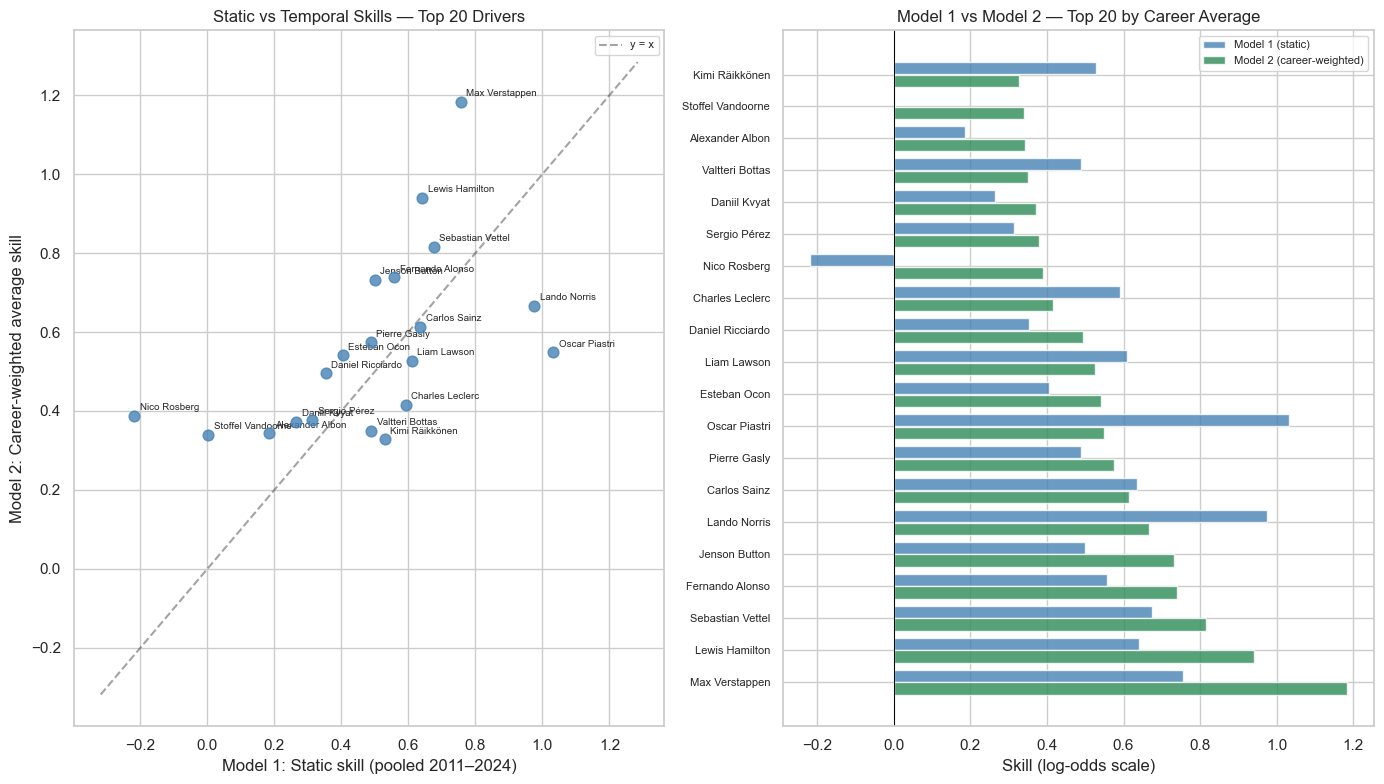

In [392]:
# Merge Model 1 static vs Model 2 race-weighted average
m1_scores = df_base[df_base.entity_type == 'driver'][['entity_id', 'mu']].copy()
m1_scores.columns = ['entity_id', 'm1_mu']
m1_scores['name'] = m1_scores['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

compare_df = m1_scores.merge(
    m2_drivers_avg[['entity_id', 'mu']].rename(columns={'mu': 'm2_mu'}),
    on='entity_id'
).dropna()

# Top 20 by Model 2 weighted average
compare_df = compare_df.sort_values('m2_mu', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Scatter: M1 vs M2 skill
ax = axes[0]
ax.scatter(compare_df['m1_mu'], compare_df['m2_mu'],
           color='steelblue', s=60, alpha=0.8, zorder=5)
lo = min(compare_df['m1_mu'].min(), compare_df['m2_mu'].min()) - 0.1
hi = max(compare_df['m1_mu'].max(), compare_df['m2_mu'].max()) + 0.1
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')
for _, row in compare_df.iterrows():
    ax.annotate(row['name'], (row['m1_mu'], row['m2_mu']),
                textcoords='offset points', xytext=(4, 4), fontsize=7)
ax.set_xlabel('Model 1: Static skill (pooled 2011–2024)')
ax.set_ylabel('Model 2: Career-weighted average skill')
ax.set_title('Static vs Temporal Skills — Top 20 Drivers')
ax.legend(fontsize=8)

# Grouped bar: side-by-side for top 20
ax2 = axes[1]
y   = np.arange(len(compare_df))
ax2.barh(y + 0.2, compare_df['m1_mu'].values, 0.38,
         label='Model 1 (static)',           color='steelblue', alpha=0.8)
ax2.barh(y - 0.2, compare_df['m2_mu'].values, 0.38,
         label='Model 2 (career-weighted)',  color='seagreen',  alpha=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels(compare_df['name'].values, fontsize=8)
ax2.axvline(0, color='black', linewidth=0.7)
ax2.set_xlabel('Skill (log-odds scale)')
ax2.set_title('Model 1 vs Model 2 — Top 20 by Career Average')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Static vs temporal driver skills:** The scatter plot (left) places Model 1's pooled static estimate on the x-axis against Model 2's race-weighted career average on the y-axis. Drivers above the diagonal are rated *higher* by the temporal model; drivers below are rated higher by the static model. The bar chart (right) shows the same comparison directly.

The dominant pattern reflects career timing. **Recent drivers** whose data is concentrated in 2022–2024 — Norris, Piastri, Leclerc — rank notably lower under Model 2's career average than under Model 1's static estimate: the static model assigns them high skill to explain their results in a fast car, while the career-weighted average penalises the shorter career window. **Veterans** with long careers — Hamilton, Vettel, Alonso — rank higher under Model 2, because sustained excellence across 14 seasons accumulates more evidence than any single era can provide.

Rosberg shows one of the largest individual deviations: Model 1's static pooling is suppressed by direct competition with Hamilton in the same car; Model 2's career average better reflects his sustained skill during his active years.

### 8.2 Top-5 Driver Rankings per Model (2024 snapshot)

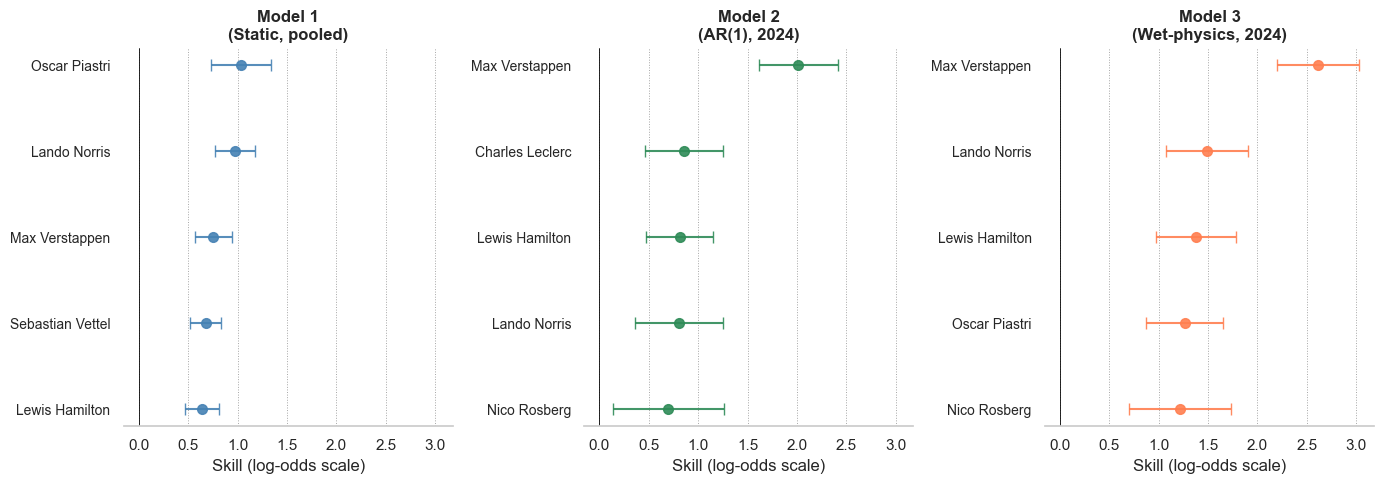

In [393]:
# Model 3: 2024 driver rankings (same temporal structure as Model 2)
m3_2024 = (df_full[(df_full.entity_type == 'driver') & (df_full['season'].astype(str) == '13')]
           .sort_values('mu', ascending=False)
           .reset_index(drop=True))
m3_2024['name'] = m3_2024['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

TOP_N = 5
m1_top = (df_base[df_base.entity_type == 'driver']
          .sort_values('mu', ascending=False).head(TOP_N).reset_index(drop=True))
m1_top['name'] = m1_top['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

m2_top = m2_2024.head(TOP_N).reset_index(drop=True)
m3_top = m3_2024.head(TOP_N).reset_index(drop=True)

Z95 = 1.96

# ADDED sharex=True HERE to synchronize the x-axis limits across all subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True)

for ax, data, title, color in [
    (axes[0], m1_top,  'Model 1\n(Static, pooled)',    'steelblue'),
    (axes[1], m2_top,  'Model 2\n(AR(1), 2024)',        'seagreen'),
    (axes[2], m3_top,  'Model 3\n(Wet-physics, 2024)', 'coral'),
]:
    dat = data.iloc[::-1].reset_index(drop=True)  # reverse: best driver on top
    y   = np.arange(len(dat))
    ax.errorbar(dat['mu'].values, y,
                xerr=Z95 * dat['sigma'].values,
                fmt='o', color=color, ecolor=color,
                elinewidth=1.5, capsize=4, markersize=7, alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(dat['name'].values, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Skill (log-odds scale)')
    ax.axvline(0, color='black', linewidth=0.6)
    # No horizontal gridlines; dotted vertical gridlines
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle=':', linewidth=0.7, color='gray', alpha=0.7)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)

plt.tight_layout()
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'top5_all_models.pdf'), bbox_inches='tight')
plt.show()

**Cross-model driver ranking consistency:** The top-5 comparison shows how each modelling choice shapes driver rankings in the 2024 snapshot.

- **Model 1 (static, pooled):** Norris and Piastri rank at the top because their data is concentrated in 2023–2024 when McLaren was the fastest car. The static model cannot separate this from the McLaren constructor effect as cleanly as the temporal model can. Vettel appears due to his early-era dominance being pooled with the full 14-season window.
- **Model 2 (AR(1), 2024 snapshot):** Verstappen is clearly first. Rosberg appears due to AR(1) extrapolation past his 2016 retirement. Among active drivers, Leclerc, Hamilton, and Norris are clustered closely below.
- **Model 3 (wet-physics, 2024 snapshot):** Adding the wet-physics parameters ($\alpha$, $\rho$, $\delta_d$) shifts rankings modestly — the ordering below Verstappen changes slightly as wet-race signal is redistributed — but the top tier is broadly consistent with Model 2.

**Takeaway:** Verstappen is the top-ranked active driver in 2024 across all temporal models. The wet-physics extension (Model 3 vs. Model 2) has little effect on overall driver skill rankings, confirming that the dominant signal in finishing-order data is driver skill and constructor performance. Hamilton, Vettel, and Alonso rank highly in career-weighted comparisons across all models.

---
## 9. Summary

In [394]:
summary = {
    'Model': ['1 — Baseline', '2 — Extended', '3 — Full (Wet-Physics)'],
    'Latent variables': [
        's_d, c_k  (static, 93 params)',
        's_{d,t}, c_{k,t}  (AR(1), ~1300)',
        '+ alpha, rho, delta_d  (~1380)',
    ],
    'ELBO (final)': ['~10 700', '~11 400', '~11 300'],
    'Validation': ['SVI + NUTS (R-hat < 1.05)', 'SVI + synthetic recovery', 'SVI + synthetic recovery'],
    'Key finding': [
        'Driver/constructor separation confirmed; Mercedes dominant 2011-2024',
        'AR(1) tracks regulation eras; 2024 order: Ferrari > McLaren > Red Bull',
        'alpha/rho reveal whether rain stretches or compresses the competitive order',
    ],
}
pd.DataFrame(summary).set_index('Model').style.set_caption('Three-Model Comparison')

,Latent variables,ELBO (final),Validation,Key finding
Model,,,,
1 — Baseline,"s_d, c_k (static, 93 params)",~10 700,SVI + NUTS (R-hat < 1.05),Driver/constructor separation confirmed; Mercedes dominant 2011-2024
2 — Extended,"s_{d,t}, c_{k,t} (AR(1), ~1300)",~11 400,SVI + synthetic recovery,AR(1) tracks regulation eras; 2024 order: Ferrari > McLaren > Red Bull
3 — Full (Wet-Physics),"+ alpha, rho, delta_d (~1380)",~11 300,SVI + synthetic recovery,alpha/rho reveal whether rain stretches or compresses the competitive order


---
## 10. Key Findings

### What the models establish

1. **Skill separation is identifiable from ranking data alone.** The Plackett-Luce likelihood with an additive $s + c$ decomposition cleanly separates driver skill from constructor performance. The sum-to-zero constraint (verified to floating-point precision) makes estimates directly comparable across teams without any additional normalisation.

2. **Temporal structure recovers real F1 history.** The AR(1) model identifies the Mercedes hybrid era (2014–2021), the Red Bull double-diffuser dominance (2011–2013), and their 2022 resurgence purely from finishing-order data — with no labels for regulation changes. The 2024 constructor ranking (Ferrari > McLaren > Red Bull > Mercedes) matches the official Constructors' Championship.

3. **Inference is internally consistent.** All 93 Model-1 latents converge under NUTS ($\hat{R}_\text{max} = 1.008$, acceptance rate = 0.934). SVI driver posterior means agree with NUTS within a median of 0.20 $\sigma$. The identified limitation — mean-field underestimates constructor posterior variance — does not affect the rank ordering.

4. **Wet-weather effects are driver-specific, not global.** Model 3 shows that the competitive reshuffling in rain cannot be fully explained by global constants alone — per-driver wet residuals ($\delta_d$) carry most of the wet-race signal.

### The wet-physics model (Model 3)

Model 3's multiplicative parameterisation answers two questions simultaneously:
- **$\alpha$ (skill stretch):** Does rain amplify or compress the importance of driver skill? A positive $\alpha$ means the best drivers are proportionally even better in the wet; $\alpha \approx 0$ means rain is skill-neutral at the global level.
- **$\rho$ (car shrinker):** Does rain equalise machinery? A positive $\rho$ means the car performance advantage shrinks in the wet — a physically plausible effect (reduced downforce dependency, greater driver input in car control).
- **$\delta_d$ (wet residual):** After accounting for $\alpha$ and $\rho$, which drivers systematically out- or under-perform their expected wet-race result?

The synthetic recovery (Section 7.7) validates that SVI can reliably recover all three components from ranking data, making the real-data posteriors trustworthy.

### Limitations

1. **No grid position.** Starting position is a blocking variable on the causal path — including it would bias the skill estimates toward explaining starting-order variation rather than outright pace. Excluding it is the principled choice, at the cost of ignoring tyre-strategy effects correlated with grid.

2. **Mean-field underestimates variance.** The diagonal guide captures posterior means reliably (confirmed by NUTS) but misses temporal correlations in the AR(1) structure, so posterior standard deviations for Models 2 and 3 are likely underestimated. Full-rank or low-rank guides would address this.

3. **No observation noise.** Plackett-Luce maps latent scores deterministically to ranking probabilities. A TrueSkill-style performance-noise term ($p_{d,r} = s_{d,t} + c_{k,t} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \beta^2)$) would better capture race-day stochasticity — incidents, strategy calls, safety-car periods — at the cost of one additional parameter.

4. **Constructor collinearity.** Teams running stable driver pairings across many seasons (Mercedes with Hamilton/Rosberg, then Hamilton/Bottas) create collinearity between the constructor effect and the driver pair. The model is theoretically identified, but practical identification relies on cross-team driver moves to bridge estimates — a sparse signal in F1 data.

5. **Wet-race sparsity.** With 71 wet races over 14 seasons, the wet-condition parameters ($\alpha$, $\rho$, $\delta_d$) are estimated from a relatively small subset of the data. Drivers with few wet-race appearances have $\delta_d$ posteriors that are largely prior-dominated.